<a href="https://colab.research.google.com/github/franksalomon/home-credit-default-risk-tfm/blob/main/agrupacion_de_categorias_application_train_%2B_bureau_%2B_previous_application.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
 # =========================================================
# 1. IMPORTING LIBRARIES
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import zipfile

import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)

In [2]:
# =========================================================
# 2. LOADING THE DATASET
# =========================================================

file_id = "1wfVaFjMmoIUVLvfwamCEy1jlWXpoMxK5"
url = f"https://drive.google.com/uc?id={file_id}"

zip_path = "/content/home-credit-default-risk.zip"
extract_path = "/content/data"

gdown.download(url, zip_path, quiet=False)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

df = pd.read_csv("/content/data/application_train.csv")
bureau = pd.read_csv("/content/data/bureau.csv")
previous_application = pd.read_csv("/content/data/previous_application.csv")

df.head()

Downloading...
From (original): https://drive.google.com/uc?id=1wfVaFjMmoIUVLvfwamCEy1jlWXpoMxK5
From (redirected): https://drive.google.com/uc?id=1wfVaFjMmoIUVLvfwamCEy1jlWXpoMxK5&confirm=t&uuid=27a9e5d6-8673-4c38-ba60-ffedef22e809
To: /content/home-credit-default-risk.zip
100%|██████████| 722M/722M [00:11<00:00, 63.5MB/s]


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [3]:
# =========================================================
# 3. OVERVIEW OF THE MAIN DATASET
# =========================================================

df.shape

(307511, 122)

In [4]:
df["SK_ID_CURR"].nunique()

307511

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [6]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [8]:
df.isna().sum().sort_values(ascending=False).head(20)

,0
COMMONAREA_AVG,214865
COMMONAREA_MODE,214865
COMMONAREA_MEDI,214865
NONLIVINGAPARTMENTS_MEDI,213514
NONLIVINGAPARTMENTS_MODE,213514
NONLIVINGAPARTMENTS_AVG,213514
FONDKAPREMONT_MODE,210295
LIVINGAPARTMENTS_AVG,210199
LIVINGAPARTMENTS_MEDI,210199
LIVINGAPARTMENTS_MODE,210199


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# =========================================================
# 4. CHECKING THE TARGET VARIABLE
# =========================================================

df["TARGET"].value_counts()

,count
TARGET,
0,282686
1,24825


In [11]:
df["TARGET"].value_counts(normalize=True) * 100

,proportion
TARGET,
0,91.927118
1,8.072882


In [12]:
print("Percentage of clients with default:")
print(round(df["TARGET"].mean() * 100, 2), "%")

Percentage of clients with default:
8.07 %


In [13]:
# =========================================================
# 5. CREATING A WORKING DATAFRAME
# =========================================================
# A working copy of the main application table is created.
# This dataframe will be used as the main modeling base.
# The auxiliary tables, such as bureau and previous_application,
# will be used later to create aggregated variables and merge them into df1.

df1 = df.copy()

df1.shape

(307511, 122)

In [14]:
# =========================================================
# 5. EXPLORING BUREAU TABLE
# =========================================================
# The bureau table is kept as an auxiliary table.
# It will be explored and later summarized by SK_ID_CURR.
bureau.shape

(1716428, 17)

In [15]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [16]:
bureau.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB


In [17]:
bureau.duplicated().sum()

np.int64(0)

In [18]:
bureau.isna().sum().sort_values(ascending=False).head(20)

,0
AMT_ANNUITY,1226791
AMT_CREDIT_MAX_OVERDUE,1124488
DAYS_ENDDATE_FACT,633653
AMT_CREDIT_SUM_LIMIT,591780
AMT_CREDIT_SUM_DEBT,257669
DAYS_CREDIT_ENDDATE,105553
AMT_CREDIT_SUM,13
SK_ID_CURR,0
SK_ID_BUREAU,0
CREDIT_DAY_OVERDUE,0


In [19]:
# Number of unique clients with records in bureau
bureau["SK_ID_CURR"].nunique()

# Note:
# The number of unique clients in bureau is lower than in the main application table.
# This is expected, since not all applicants have previous credit records in the bureau dataset.
# Therefore, bureau will first be aggregated at SK_ID_CURR level and then merged with the main table using a left join.

305811

In [20]:
bureau["CREDIT_ACTIVE"].value_counts()

,count
CREDIT_ACTIVE,
Closed,1079273
Active,630607
Sold,6527
Bad debt,21


In [21]:
# =========================================================
# 6. EXPLORING PREVIOUS APPLICATION TABLE
# =========================================================
# The previous_application table is also kept as an auxiliary table.
# It will be explored and later summarized by SK_ID_CURR.

previous_application.shape

(1670214, 37)

In [22]:
previous_application.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.0,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
previous_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

In [24]:
previous_application.isna().sum().sort_values(ascending=False).head(20)

,0
RATE_INTEREST_PRIVILEGED,1664263
RATE_INTEREST_PRIMARY,1664263
AMT_DOWN_PAYMENT,895844
RATE_DOWN_PAYMENT,895844
NAME_TYPE_SUITE,820405
DAYS_TERMINATION,673065
DAYS_FIRST_DRAWING,673065
DAYS_FIRST_DUE,673065
DAYS_LAST_DUE_1ST_VERSION,673065
DAYS_LAST_DUE,673065


In [25]:
previous_application.duplicated().sum()

np.int64(0)

In [26]:
previous_application["SK_ID_CURR"].nunique()

338857

In [27]:
previous_application["NAME_CONTRACT_STATUS"].value_counts()

,count
NAME_CONTRACT_STATUS,
Approved,1036781
Canceled,316319
Refused,290678
Unused offer,26436


In [28]:
# =========================================================
# 7. CREATING AGGREGATED BUREAU VARIABLES
# =========================================================

# In the Home Credit dataset, time variables are measured relative to
# the current loan application date. Negative values mean events occurred
# in the past, while positive values may refer to future expected dates.

bureau["CREDIT_DURATION_DAYS"] = (
    bureau["DAYS_CREDIT_ENDDATE"] - bureau["DAYS_CREDIT"]
)

# Bureau may contain multiple previous credits for the same customer.
# Therefore, the data is grouped by SK_ID_CURR to create aggregated features.
# Each new column summarizes the customer's previous credit history.

bureau_agg = (
    bureau
    .groupby("SK_ID_CURR")
    .agg(
        n_bureau_credits=("SK_ID_BUREAU", "count"),
        n_active_credits=("CREDIT_ACTIVE", lambda x: (x == "Active").sum()),  # Lambda is used to count credits that meet a specific condition.
        n_closed_credits=("CREDIT_ACTIVE", lambda x: (x == "Closed").sum()),  # True values are treated as 1 and False values as 0.
        mean_credit_days_overdue=("CREDIT_DAY_OVERDUE", "mean"),

        # min_count=1 is used so that the sum remains NaN when all values of the monetary variable are missing for a client.
        # This avoids converting absence of observed monetary information into an artificial zero during aggregation.
        sum_credit_debt=("AMT_CREDIT_SUM_DEBT", lambda x: x.sum(min_count=1)),
        sum_credit_limit=("AMT_CREDIT_SUM_LIMIT", lambda x: x.sum(min_count=1)),
        mean_credit_duration=("CREDIT_DURATION_DAYS", "mean")
    )
    .reset_index()
)

bureau_agg.head()

,SK_ID_CURR,n_bureau_credits,n_active_credits,n_closed_credits,mean_credit_days_overdue,sum_credit_debt,sum_credit_limit,mean_credit_duration
0,100001,7,3,4,0.0,596686.5,0.000,817.428571
1,100002,8,2,6,0.0,245781.0,31988.565,719.833333
2,100003,4,1,3,0.0,0.0,810000.000,856.250000
3,100004,2,0,2,0.0,0.0,0.000,378.500000
4,100005,3,2,1,0.0,568408.5,0.000,630.000000


In [29]:
bureau_agg.shape

(305811, 8)

In [30]:
bureau_agg.isna().sum().sort_values(ascending=False)

,0
sum_credit_limit,25308
sum_credit_debt,8372
mean_credit_duration,2585
SK_ID_CURR,0
n_closed_credits,0
n_active_credits,0
n_bureau_credits,0
mean_credit_days_overdue,0


In [31]:
# =========================================================
# 8. CREATING AGGREGATED PREVIOUS APPLICATION VARIABLES
# =========================================================

previous_agg = (
    previous_application
    .groupby("SK_ID_CURR")
    .agg(
        n_previous_applications=("SK_ID_PREV", "count"),
        n_approved_previous=("NAME_CONTRACT_STATUS", lambda x: (x == "Approved").sum()),
        n_refused_previous=("NAME_CONTRACT_STATUS", lambda x: (x == "Refused").sum()),
        mean_previous_credit_amount=("AMT_CREDIT", "mean"),

        # Since DAYS_DECISION is measured in negative days, the maximum value corresponds to the most recent application.
        # This variable captures how recently the client interacted with the credit application process.
        last_previous_application_days=("DAYS_DECISION", "max")
    )
    .reset_index()
)

# Approval rate summarizes the proportion of previous applications that were approved for each client.
# It captures the client's historical acceptance pattern in previous credit applications.
previous_agg["approval_rate_previous"] = (
    previous_agg["n_approved_previous"] /
    previous_agg["n_previous_applications"]
)

previous_agg.head()

,SK_ID_CURR,n_previous_applications,n_approved_previous,n_refused_previous,mean_previous_credit_amount,last_previous_application_days,approval_rate_previous
0,100001,1,1,0,23787.00,-1740,1.0
1,100002,1,1,0,179055.00,-606,1.0
2,100003,3,3,0,484191.00,-746,1.0
3,100004,1,1,0,20106.00,-815,1.0
4,100005,2,1,0,20076.75,-315,0.5


In [32]:
previous_agg.shape

(338857, 7)

In [33]:
previous_agg.isna().sum().sort_values(ascending=False)

,0
SK_ID_CURR,0
n_previous_applications,0
n_approved_previous,0
n_refused_previous,0
mean_previous_credit_amount,0
last_previous_application_days,0
approval_rate_previous,0


In [34]:
# =========================================================
# 9. CREATING A WORKING DATAFRAME
# =========================================================

df1 = df.copy()

df1.shape

(307511, 122)

In [35]:
# Merge aggregated external tables into the main dataset using SK_ID_CURR.
# A left join is used to preserve all clients from the main application table.

df1 = df1.merge(
    bureau_agg,
    on="SK_ID_CURR",
    how="left"
)

df1 = df1.merge(
    previous_agg,
    on="SK_ID_CURR",
    how="left"
)

In [36]:
df1[
    [
        "SK_ID_CURR",
        "n_bureau_credits",
        "n_active_credits",
        "n_closed_credits",
        "n_previous_applications",
        "n_approved_previous",
        "n_refused_previous",
        "approval_rate_previous"
    ]
].head()

,SK_ID_CURR,n_bureau_credits,n_active_credits,n_closed_credits,n_previous_applications,n_approved_previous,n_refused_previous,approval_rate_previous
0,100002,8.0,2.0,6.0,1.0,1.0,0.0,1.000000
1,100003,4.0,1.0,3.0,3.0,3.0,0.0,1.000000
2,100004,2.0,0.0,2.0,1.0,1.0,0.0,1.000000
3,100006,NaN,NaN,NaN,9.0,5.0,1.0,0.555556
4,100007,1.0,0.0,1.0,6.0,6.0,0.0,1.000000


In [37]:
# Checking missing values generated after the left joins

df1[
    [
        "n_bureau_credits",
        "n_active_credits",
        "n_closed_credits",
        "mean_credit_days_overdue",
        "sum_credit_debt",
        "sum_credit_limit",
        "mean_credit_duration",
        "n_previous_applications",
        "n_approved_previous",
        "n_refused_previous",
        "mean_previous_credit_amount",
        "last_previous_application_days",
        "approval_rate_previous"
    ]
].isna().sum()


,0
n_bureau_credits,44020
n_active_credits,44020
n_closed_credits,44020
mean_credit_days_overdue,44020
sum_credit_debt,51380
sum_credit_limit,65069
mean_credit_duration,46269
n_previous_applications,16454
n_approved_previous,16454
n_refused_previous,16454


In [38]:
bureau_agg["n_bureau_credits"].isna().sum()

np.int64(0)

In [39]:
previous_agg["n_previous_applications"].isna().sum()

np.int64(0)

In [40]:
# Before filling missing values with 0, binary history indicators are created
# to preserve whether each client had records in the external tables.
#
# This step is based on the previous missing-value checks:
# - bureau_agg["n_bureau_credits"].isna().sum() = 0
# - previous_agg["n_previous_applications"].isna().sum() = 0
#
# Therefore, within the aggregated tables, these count variables are complete.
# If they become NaN after the left joins with the main application table,
# it means that the client did not have matching records in the corresponding
# external table.
#
# The variables n_bureau_credits and n_previous_applications are used as key
# indicators because they are count variables that directly represent the
# existence of previous records for each client.
#
# Other variables are less suitable for this purpose. For example, monetary
# or duration variables such as sum_credit_limit, sum_credit_debt or
# mean_credit_duration may be NaN even when the client does have bureau history,
# because the original information may be missing for those specific fields.
# In contrast, count variables such as n_bureau_credits, n_active_credits,
# n_closed_credits and n_previous_applications have low risk of internal
# missing values once the client exists in the aggregated table.
#
# For previous_application, the risk is lower in this case because the
# aggregated variables did not show missing values before the join. Thus,
# NaN values after the join mainly indicate absence of previous application
# records.
#
# These indicators allow the model to distinguish between:
# - clients with no bureau / previous_application history;
# - clients with history but with some specific missing information.
#
# This information would be lost if all missing values were directly filled
# with 0 without first creating these indicators.

df1["has_bureau_history"] = df1["n_bureau_credits"].notna().astype(int)

df1["has_previous_application_history"] = (
    df1["n_previous_applications"].notna().astype(int)
)

In [41]:
# Count variables from bureau and previous_application are filled with zero
# after creating the corresponding history indicators.
#
# For bureau count variables, missing values after the left join indicate that
# the client had no matching records in bureau_agg.
#
# For previous_application count variables, missing values after the left join
# indicate that the client had no matching records in previous_agg.
#
# Since these variables represent counts, absence of records is represented as 0.

history_count_cols = [
    "n_bureau_credits",
    "n_active_credits",
    "n_closed_credits",
    "n_previous_applications",
    "n_approved_previous",
    "n_refused_previous"
]

df1[history_count_cols] = df1[history_count_cols].fillna(0)


In [42]:
df1[history_count_cols].isna().sum()

,0
n_bureau_credits,0
n_active_credits,0
n_closed_credits,0
n_previous_applications,0
n_approved_previous,0
n_refused_previous,0


In [43]:
# Specific indicators are created for bureau monetary variables before imputation.
# These variables may be missing even for clients with bureau history, because
# the original monetary information was not always reported.

df1["has_credit_debt_info"] = df1["sum_credit_debt"].notna().astype(int)
df1["has_credit_limit_info"] = df1["sum_credit_limit"].notna().astype(int)

history_sum_cols = [
    "sum_credit_debt",
    "sum_credit_limit"
]

# For clients without bureau history, monetary sums are set to 0 because
# there are no bureau records from which debt or credit limit could be observed.
# Missing values that remain for clients with bureau history are kept as NaN
# and will be handled later by the preprocessing pipeline.

df1.loc[df1["has_bureau_history"] == 0, history_sum_cols] = (
    df1.loc[df1["has_bureau_history"] == 0, history_sum_cols].fillna(0)
)

In [44]:
# An exploratory check showed that some missing values in these variables
# occurred among clients with bureau history, so they are not all filled with 0.
df1[history_sum_cols].isna().sum()

,0
sum_credit_debt,7360
sum_credit_limit,21049


In [45]:
# =========================================================
# 10. CREATING DERIVED VARIABLES
# =========================================================

# Age in years

df1["AGE_YEARS"] = df1["DAYS_BIRTH"] / -365

df1[["DAYS_BIRTH", "AGE_YEARS"]].head()

,DAYS_BIRTH,AGE_YEARS
0,-9461,25.920548
1,-16765,45.931507
2,-19046,52.180822
3,-19005,52.068493
4,-19932,54.608219


In [46]:
# Years employed.
# The value 365243 is a special anomalous value in DAYS_EMPLOYED.
# Since DAYS_EMPLOYED has no original missing values, the indicator below
# preserves the information that later becomes NaN after replacing 365243.

df1["DAYS_EMPLOYED_ANOMALY"] = (
    df1["DAYS_EMPLOYED"] == 365243
).astype(int)

df1["DAYS_EMPLOYED_CLEAN"] = df1["DAYS_EMPLOYED"].replace(365243, np.nan)

df1["YEARS_EMPLOYED"] = df1["DAYS_EMPLOYED_CLEAN"] / -365

In [47]:
df1[["DAYS_EMPLOYED", "DAYS_EMPLOYED_CLEAN", "YEARS_EMPLOYED", "DAYS_EMPLOYED_ANOMALY"]].head()

,DAYS_EMPLOYED,DAYS_EMPLOYED_CLEAN,YEARS_EMPLOYED,DAYS_EMPLOYED_ANOMALY
0,-637,-637.0,1.745205,0
1,-1188,-1188.0,3.254795,0
2,-225,-225.0,0.616438,0
3,-3039,-3039.0,8.326027,0
4,-3038,-3038.0,8.323288,0


In [48]:
# Other time variables

df1["YEARS_REGISTRATION"] = df1["DAYS_REGISTRATION"] / -365
df1["YEARS_ID_PUBLISH"] = df1["DAYS_ID_PUBLISH"] / -365
df1["YEARS_LAST_PHONE_CHANGE"] = df1["DAYS_LAST_PHONE_CHANGE"] / -365

df1[
    [
        "YEARS_REGISTRATION",
        "YEARS_ID_PUBLISH",
        "YEARS_LAST_PHONE_CHANGE"
    ]
].head()

,YEARS_REGISTRATION,YEARS_ID_PUBLISH,YEARS_LAST_PHONE_CHANGE
0,9.994521,5.808219,3.106849
1,3.249315,0.797260,2.268493
2,11.671233,6.934247,2.232877
3,26.939726,6.676712,1.690411
4,11.810959,9.473973,3.030137


In [49]:
df1[
    ["DAYS_REGISTRATION", "DAYS_ID_PUBLISH", "DAYS_LAST_PHONE_CHANGE"]
].describe()

,DAYS_REGISTRATION,DAYS_ID_PUBLISH,DAYS_LAST_PHONE_CHANGE
count,307511.000000,307511.000000,307510.000000
mean,-4986.120328,-2994.202373,-962.858788
std,3522.886321,1509.450419,826.808487
min,-24672.000000,-7197.000000,-4292.000000
25%,-7479.500000,-4299.000000,-1570.000000
50%,-4504.000000,-3254.000000,-757.000000
75%,-2010.000000,-1720.000000,-274.000000
max,0.000000,0.000000,0.000000


In [50]:
# Financial ratios

df1["CREDIT_INCOME_RATIO"] = (
    df1["AMT_CREDIT"] / df1["AMT_INCOME_TOTAL"]
)

df1["ANNUITY_INCOME_RATIO"] = (
    df1["AMT_ANNUITY"] / df1["AMT_INCOME_TOTAL"]
)

df1[
    [
        "AMT_CREDIT",
        "AMT_INCOME_TOTAL",
        "CREDIT_INCOME_RATIO",
        "AMT_ANNUITY",
        "ANNUITY_INCOME_RATIO"
    ]
].head()

,AMT_CREDIT,AMT_INCOME_TOTAL,CREDIT_INCOME_RATIO,AMT_ANNUITY,ANNUITY_INCOME_RATIO
0,406597.5,202500.0,2.007889,24700.5,0.121978
1,1293502.5,270000.0,4.790750,35698.5,0.132217
2,135000.0,67500.0,2.000000,6750.0,0.100000
3,312682.5,135000.0,2.316167,29686.5,0.219900
4,513000.0,121500.0,4.222222,21865.5,0.179963


In [51]:
# Bureau request variables

bureau_recent_cols = [
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK"
]

bureau_total_cols = [
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR"
]

df1["BUREAU_REQ_RECENT"] = df1[bureau_recent_cols].sum(axis=1, min_count=1)
df1["BUREAU_REQ_TOTAL"] = df1[bureau_total_cols].sum(axis=1, min_count=1)

df1[["BUREAU_REQ_RECENT", "BUREAU_REQ_TOTAL"]].head()

,BUREAU_REQ_RECENT,BUREAU_REQ_TOTAL
0,0.0,1.0
1,0.0,0.0
2,0.0,0.0
3,NaN,NaN
4,0.0,0.0


In [52]:
# =========================================================
# 11. TRAIN-TEST SPLIT
# =========================================================

df_train, df_test = train_test_split(
    df1,
    train_size=40000,
    stratify=df1["TARGET"],
    random_state=42
)

df_train = df_train.copy()
df_test = df_test.copy()

print(df_train.shape)
print(df_test.shape)

(40000, 150)
(267511, 150)


In [53]:
print(df_train["TARGET"].value_counts(normalize=True) * 100)
print(df_test["TARGET"].value_counts(normalize=True) * 100)

TARGET
0    91.9275
1     8.0725
Name: proportion, dtype: float64
TARGET
0    91.927061
1     8.072939
Name: proportion, dtype: float64


In [54]:
# Variables nuevas agregadas a df1 respecto a la tabla original

added_cols = df1.columns.difference(df.columns)

print("Variables agregadas:")
print(list(added_cols))

added_cols_table = pd.DataFrame({
    "variable_agregada": list(added_cols)
})

added_cols_table

Variables agregadas:
['AGE_YEARS', 'ANNUITY_INCOME_RATIO', 'BUREAU_REQ_RECENT', 'BUREAU_REQ_TOTAL', 'CREDIT_INCOME_RATIO', 'DAYS_EMPLOYED_ANOMALY', 'DAYS_EMPLOYED_CLEAN', 'YEARS_EMPLOYED', 'YEARS_ID_PUBLISH', 'YEARS_LAST_PHONE_CHANGE', 'YEARS_REGISTRATION', 'approval_rate_previous', 'has_bureau_history', 'has_credit_debt_info', 'has_credit_limit_info', 'has_previous_application_history', 'last_previous_application_days', 'mean_credit_days_overdue', 'mean_credit_duration', 'mean_previous_credit_amount', 'n_active_credits', 'n_approved_previous', 'n_bureau_credits', 'n_closed_credits', 'n_previous_applications', 'n_refused_previous', 'sum_credit_debt', 'sum_credit_limit']


,variable_agregada
0,AGE_YEARS
1,ANNUITY_INCOME_RATIO
2,BUREAU_REQ_RECENT
3,BUREAU_REQ_TOTAL
4,CREDIT_INCOME_RATIO
5,DAYS_EMPLOYED_ANOMALY
6,DAYS_EMPLOYED_CLEAN
7,YEARS_EMPLOYED
8,YEARS_ID_PUBLISH
9,YEARS_LAST_PHONE_CHANGE


In [55]:
# Removing identifier after the split

df_train = df_train.drop(columns=["SK_ID_CURR"])
df_test = df_test.drop(columns=["SK_ID_CURR"])

print(df_train.shape)
print(df_test.shape)

(40000, 149)
(267511, 149)


In [56]:
# =========================================================
# 12. EXPLORING NEW HISTORICAL VARIABLES
# =========================================================

history_cols = [
    "n_bureau_credits",
    "n_active_credits",
    "n_closed_credits",
    "mean_credit_days_overdue",
    "sum_credit_debt",
    "sum_credit_limit",
    "mean_credit_duration",
    "n_previous_applications",
    "n_approved_previous",
    "n_refused_previous",
    "mean_previous_credit_amount",
    "last_previous_application_days",
    "approval_rate_previous"
]

df_train[history_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
n_bureau_credits,40000.0,4.734300,4.468054e+00,0.000,1.00000,4.00,7.000,6.100000e+01
n_active_credits,40000.0,1.759625,1.810643e+00,0.000,0.00000,1.00,3.000,1.900000e+01
n_closed_credits,40000.0,2.956550,3.314089e+00,0.000,0.00000,2.00,4.000,4.800000e+01
mean_credit_days_overdue,34175.0,0.950519,2.515561e+01,0.000,0.00000,0.00,0.000,2.644000e+03
sum_credit_debt,39030.0,563930.305079,2.179043e+06,-3112461.135,0.00000,98271.63,548372.250,3.344983e+08
sum_credit_limit,37250.0,21408.408258,9.395553e+04,-391566.645,0.00000,0.00,0.000,3.112461e+06
mean_credit_duration,33886.0,1784.951939,3.268120e+03,-19610.000,452.18750,815.25,1461.000,3.367700e+04
n_previous_applications,40000.0,4.620075,4.196394e+00,0.000,2.00000,3.00,6.000,6.200000e+01
n_approved_previous,40000.0,2.886950,2.177932e+00,0.000,1.00000,2.00,4.000,2.300000e+01
n_refused_previous,40000.0,0.807450,1.802000e+00,0.000,0.00000,0.00,1.000,4.700000e+01


In [57]:
df_train[history_cols].isna().sum().sort_values(ascending=False)

,0
mean_credit_duration,6114
mean_credit_days_overdue,5825
sum_credit_limit,2750
mean_previous_credit_amount,2138
last_previous_application_days,2138
approval_rate_previous,2138
sum_credit_debt,970
n_bureau_credits,0
n_closed_credits,0
n_active_credits,0


In [58]:
df_train.groupby("TARGET")[history_cols].mean().T

TARGET,0,1
n_bureau_credits,4.757853,4.466089
n_active_credits,1.741971,1.960669
n_closed_credits,2.998341,2.480644
mean_credit_days_overdue,0.931962,1.174480
sum_credit_debt,565854.037379,542040.757436
sum_credit_limit,21731.429977,17727.250597
mean_credit_duration,1751.731603,2188.220281
n_previous_applications,4.590438,4.957572
n_approved_previous,2.900057,2.737690
n_refused_previous,0.774143,1.186745


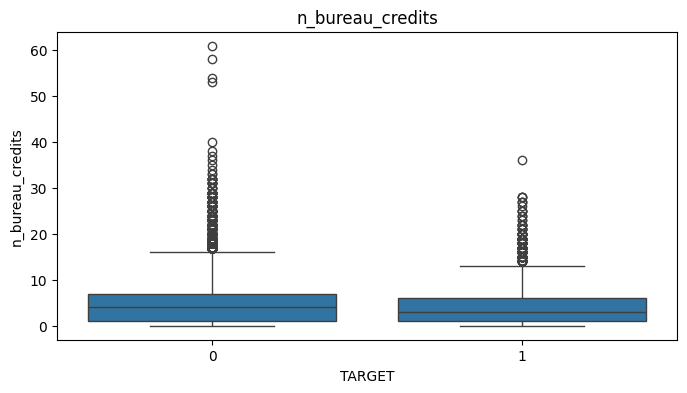

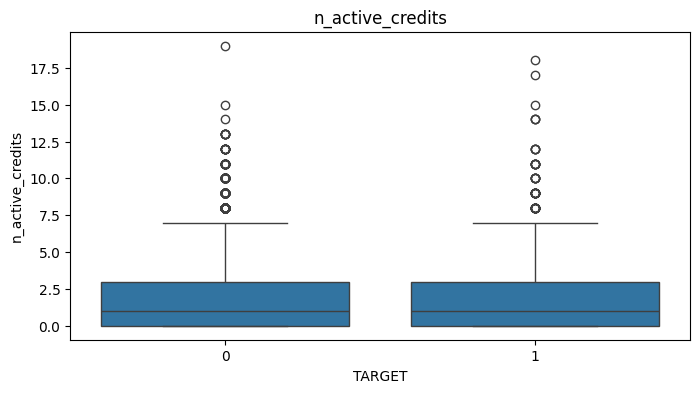

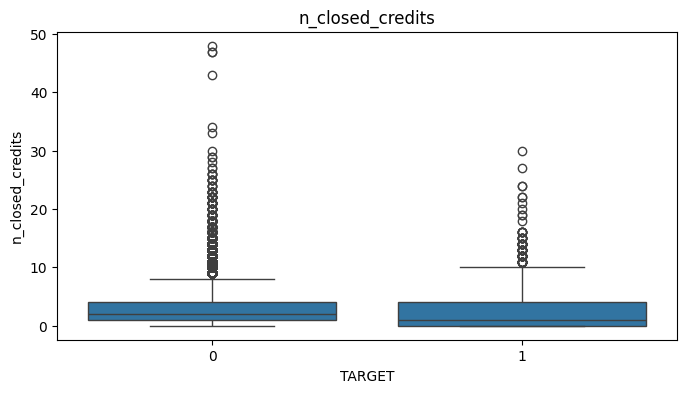

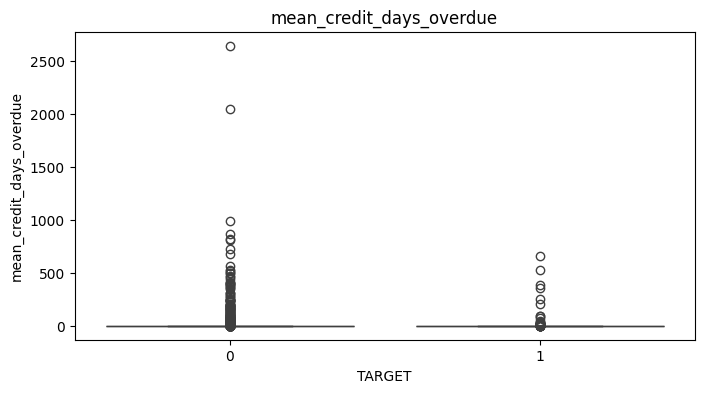

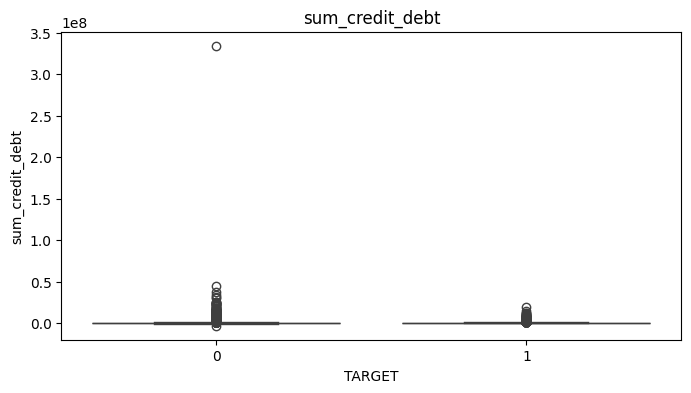

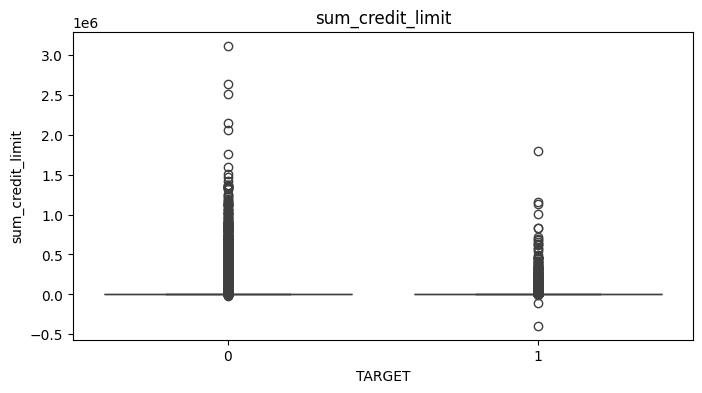

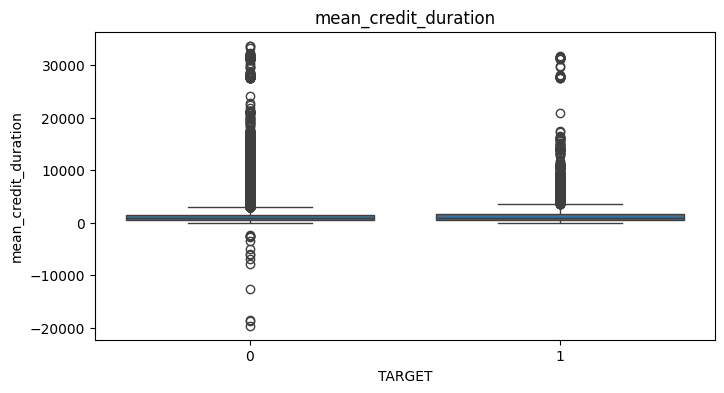

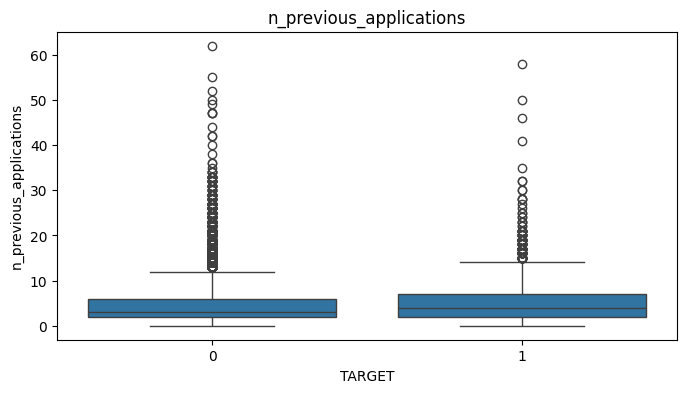

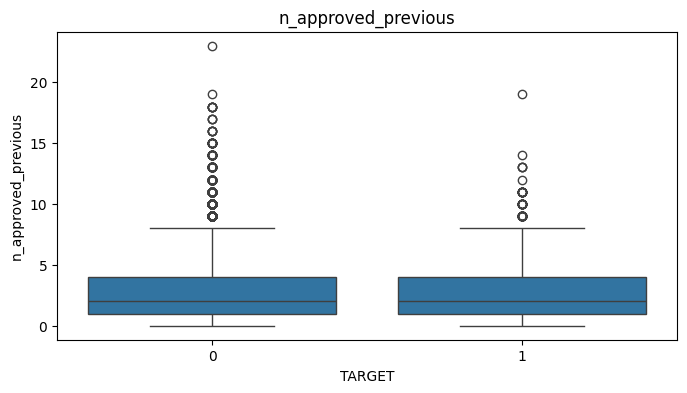

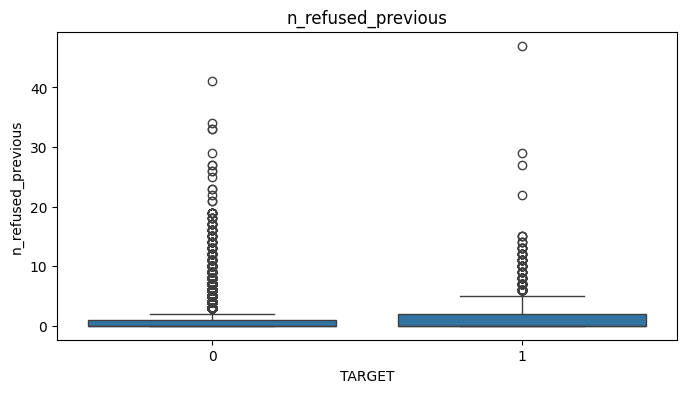

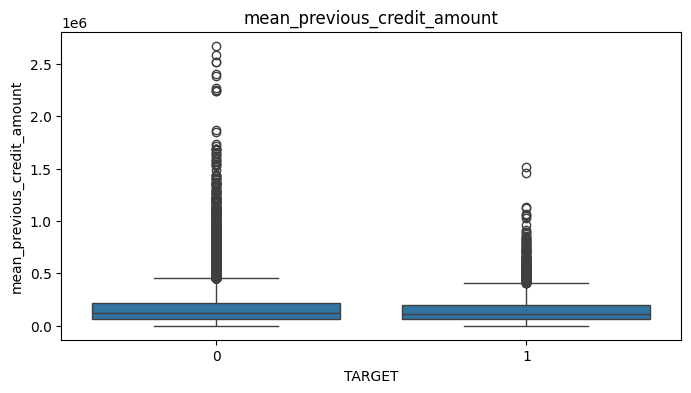

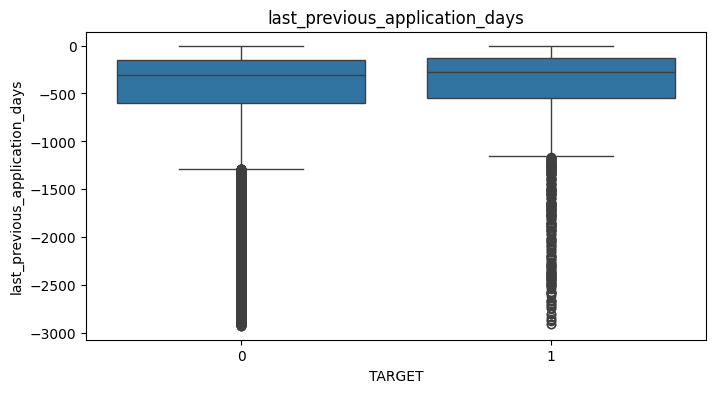

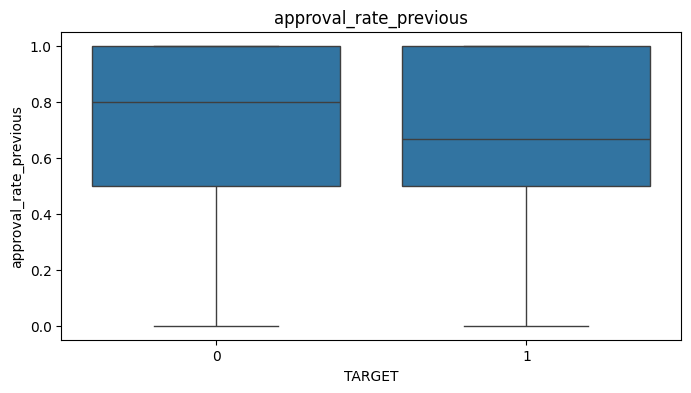

In [59]:
for col in history_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_train, x="TARGET", y=col)
    plt.title(col)
    plt.show()

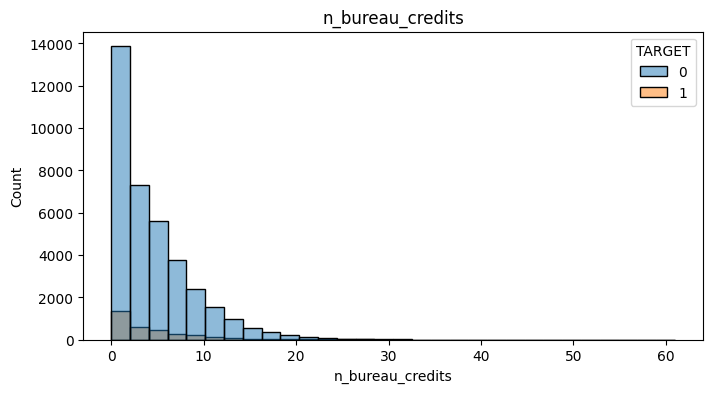

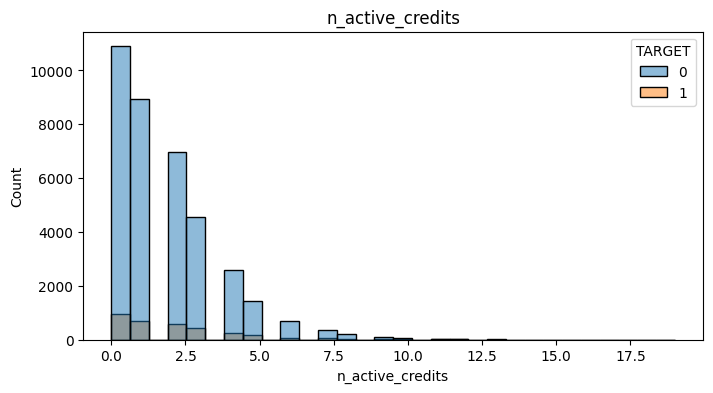

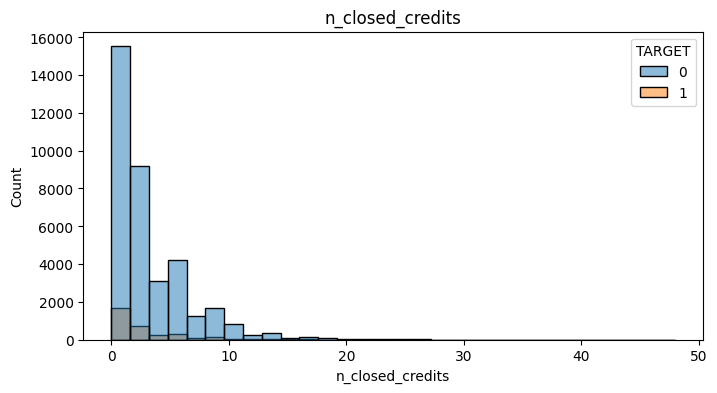

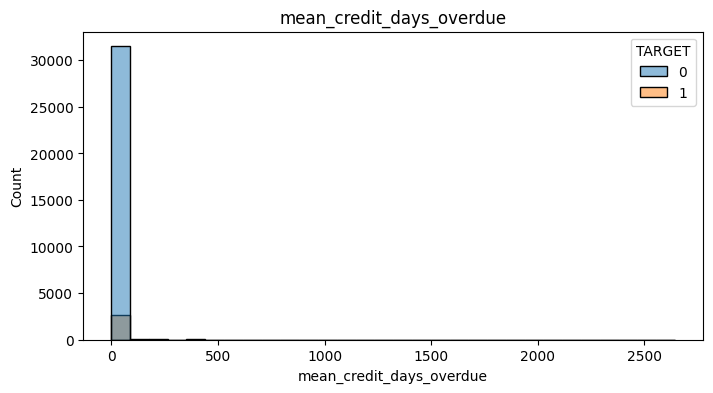

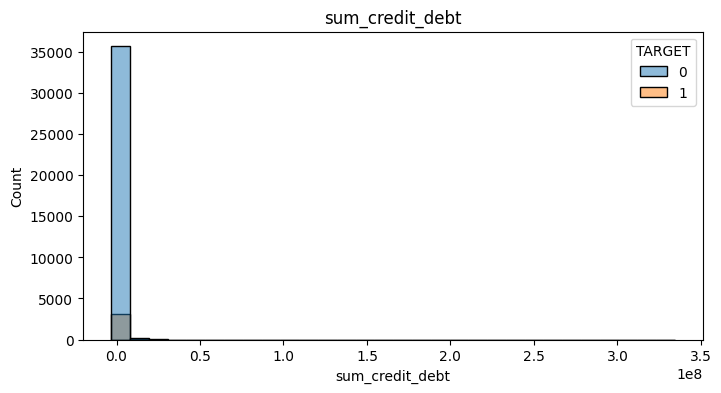

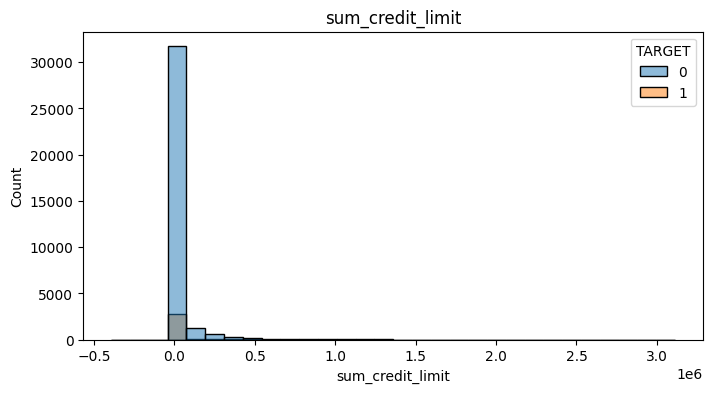

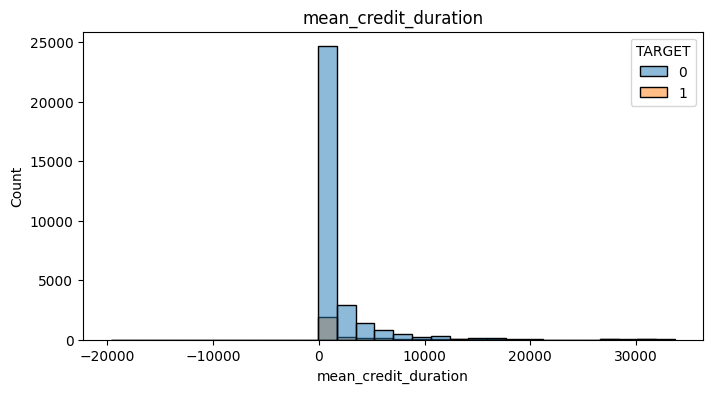

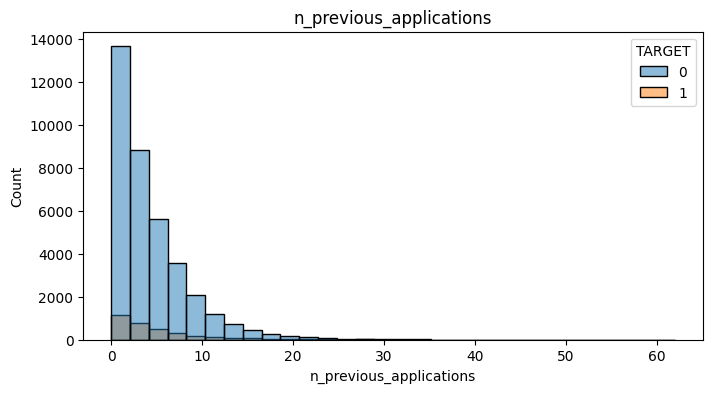

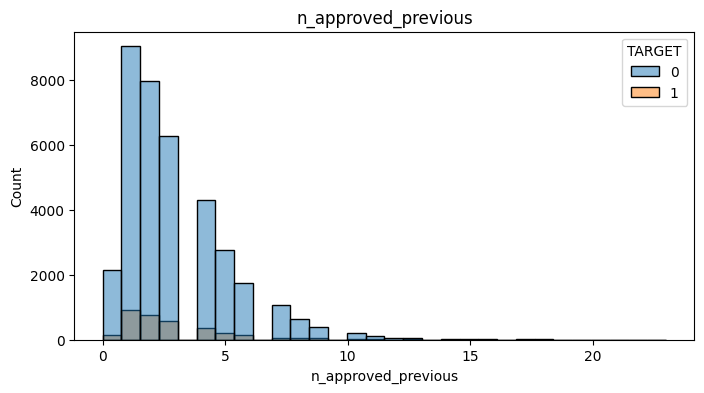

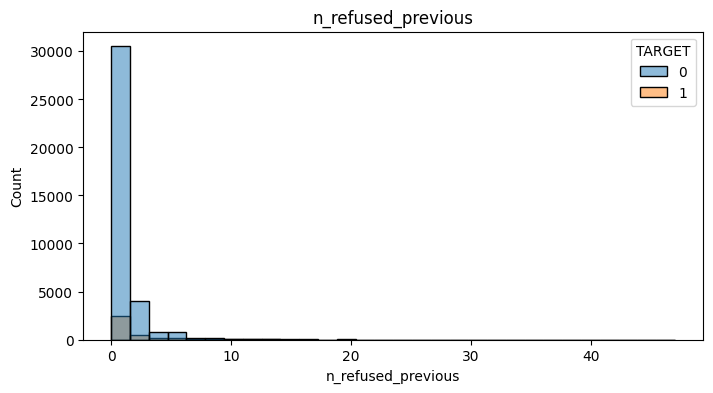

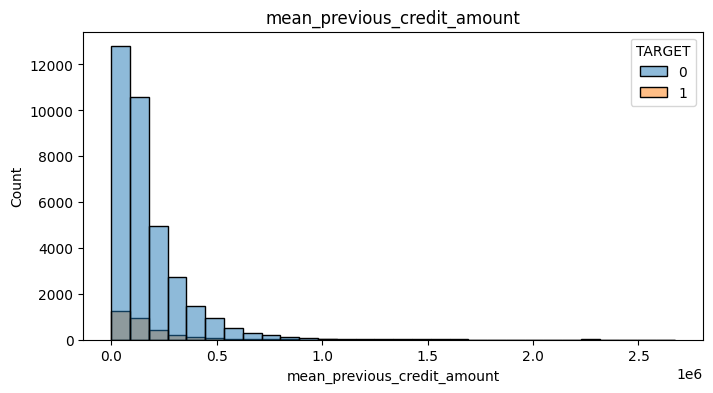

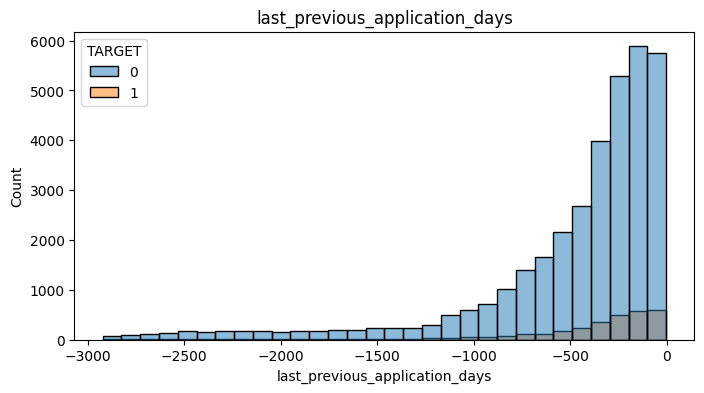

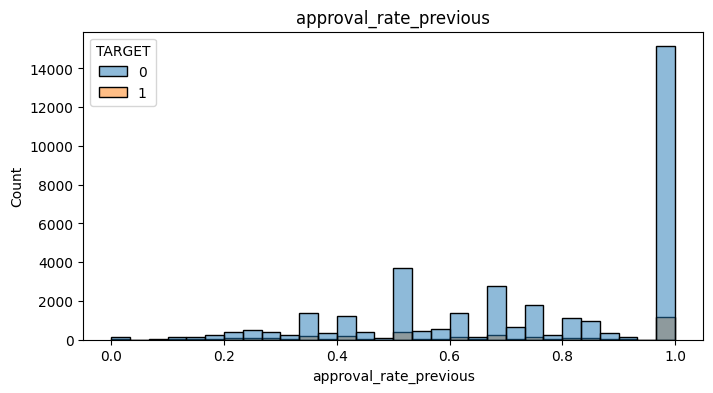

In [60]:
for col in history_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df_train, x=col, hue="TARGET", bins=30, kde=False)
    plt.title(col)
    plt.show()

In [61]:
# =========================================================
# VARIABLES FOR EDA AGAINST TARGET
# =========================================================

# Main variables created from application_train

application_num_variables = [
    "AGE_YEARS",
    "YEARS_EMPLOYED",
    "AMT_CREDIT",
    "AMT_INCOME_TOTAL",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "BUREAU_REQ_RECENT",
    "BUREAU_REQ_TOTAL",
    "DOCUMENT_COUNT"
]

# Historical variables created from bureau and previous_application

history_num_variables = [
    "n_bureau_credits",
    "n_active_credits",
    "n_closed_credits",
    "mean_credit_days_overdue",
    "sum_credit_debt",
    "sum_credit_limit",
    "mean_credit_duration",
    "n_previous_applications",
    "n_approved_previous",
    "n_refused_previous",
    "mean_previous_credit_amount",
    "last_previous_application_days",
    "approval_rate_previous"
]

# Categorical variables

cat_variables = [
    "CODE_GENDER",
    "NAME_EDUCATION_TYPE",
    "NAME_INCOME_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE"
]

application_num_variables = [col for col in application_num_variables if col in df_train.columns]
history_num_variables = [col for col in history_num_variables if col in df_train.columns]
cat_variables = [col for col in cat_variables if col in df_train.columns]

variables_eda = application_num_variables + history_num_variables + cat_variables

print(variables_eda)

['AGE_YEARS', 'YEARS_EMPLOYED', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'BUREAU_REQ_RECENT', 'BUREAU_REQ_TOTAL', 'n_bureau_credits', 'n_active_credits', 'n_closed_credits', 'mean_credit_days_overdue', 'sum_credit_debt', 'sum_credit_limit', 'mean_credit_duration', 'n_previous_applications', 'n_approved_previous', 'n_refused_previous', 'mean_previous_credit_amount', 'last_previous_application_days', 'approval_rate_previous', 'CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']


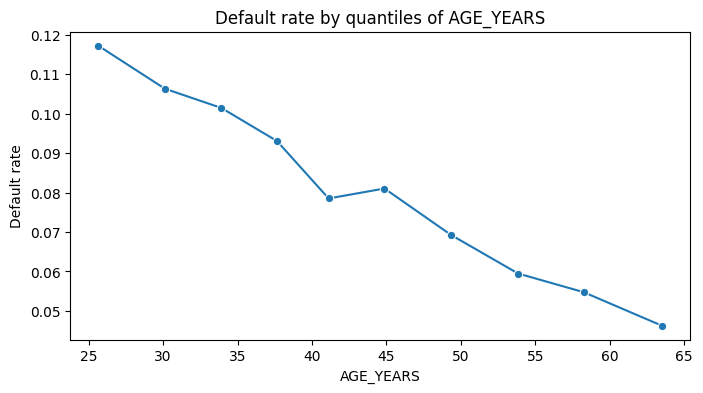

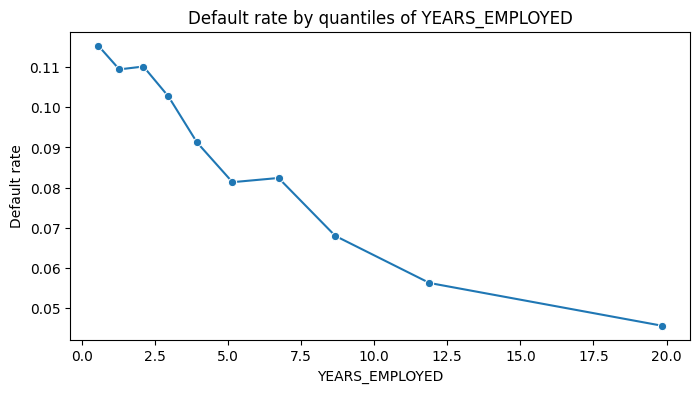

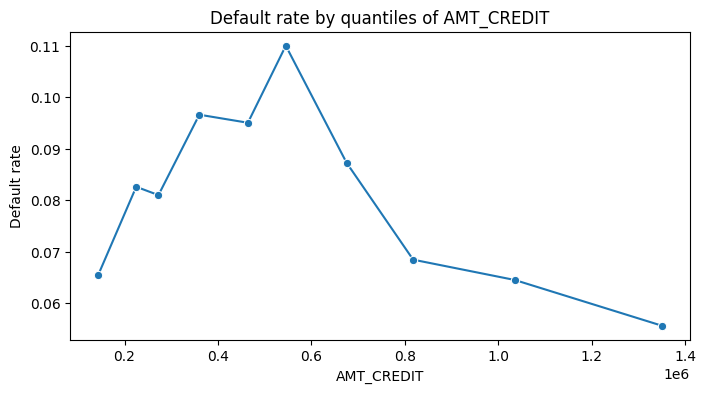

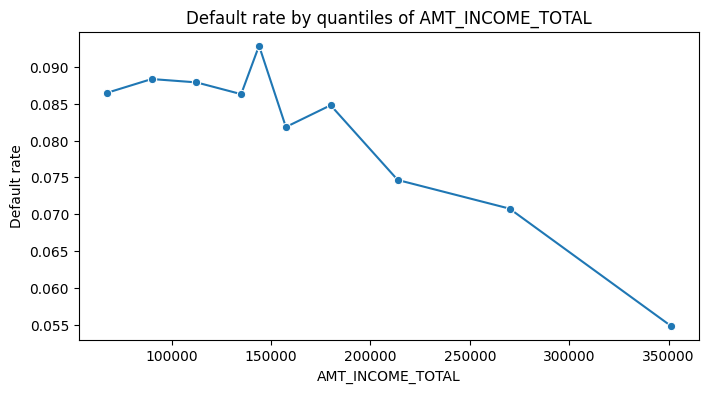

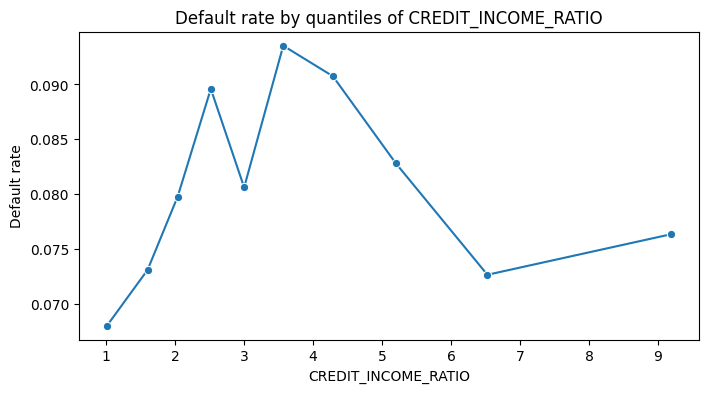

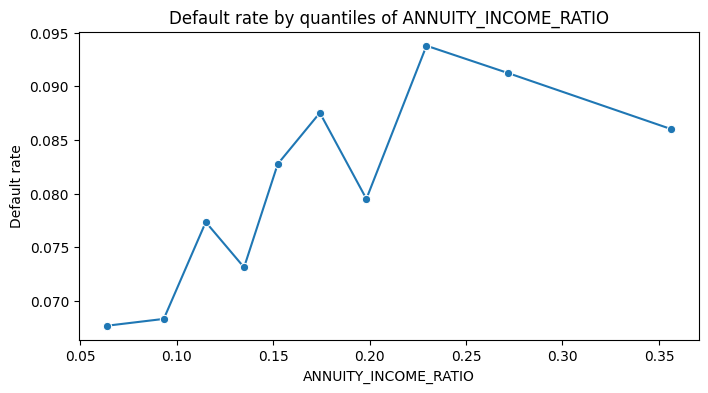

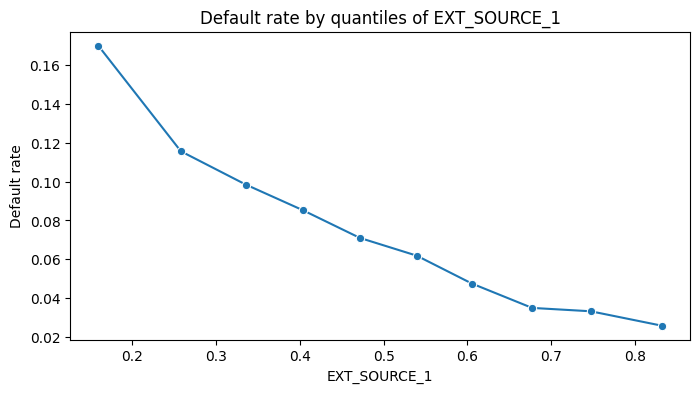

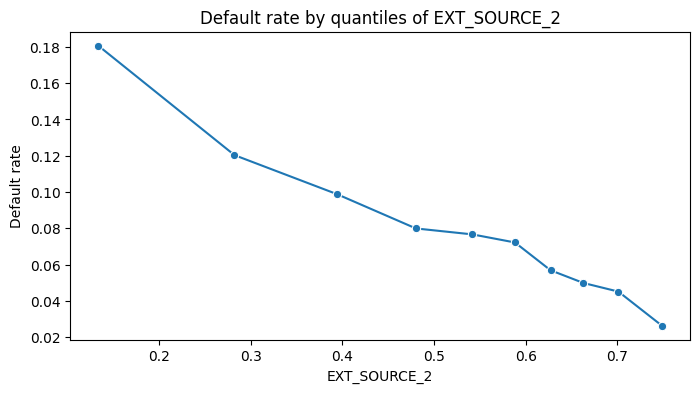

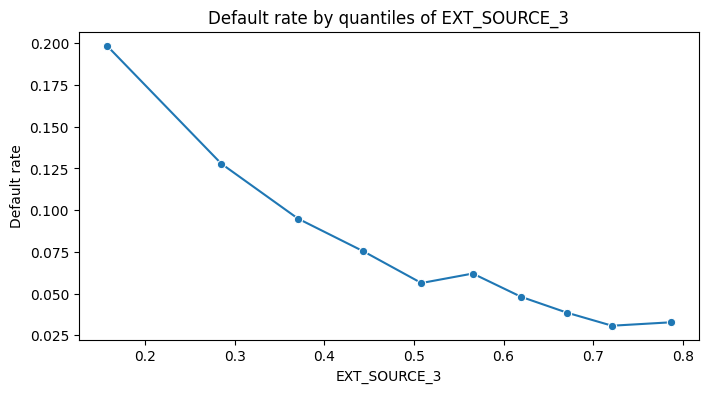

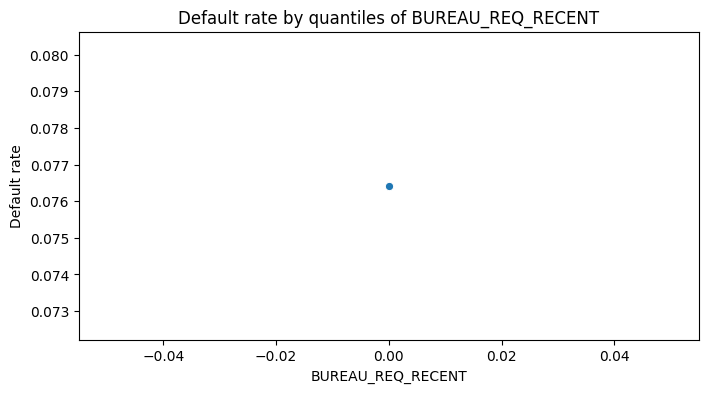

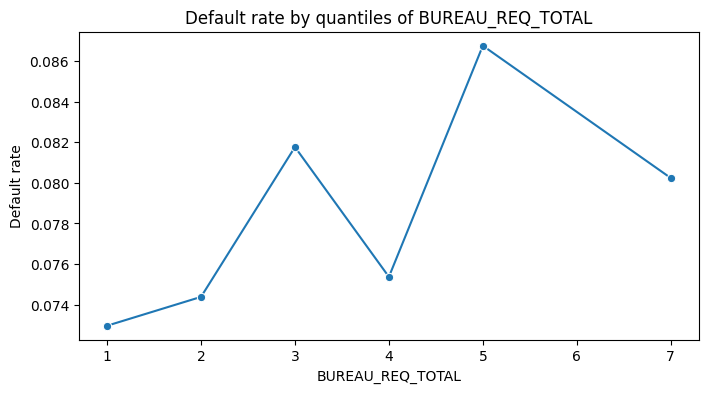

In [62]:
# =========================================================
# DEFAULT RATE BY QUANTILES OF APPLICATION VARIABLES
# =========================================================

for col in application_num_variables:

    temp = df_train[[col, "TARGET"]].dropna().copy()

    temp["bin"] = pd.qcut(
        temp[col],
        q=10,
        duplicates="drop"
    )

    summary = (
        temp.groupby("bin", observed=True)
        .agg(
            default_rate=("TARGET", "mean"),
            n_obs=("TARGET", "size"),
            median_value=(col, "median")
        )
        .reset_index()
    )

    plt.figure(figsize=(8, 4))

    sns.lineplot(
        data=summary,
        x="median_value",
        y="default_rate",
        marker="o"
    )

    plt.title(f"Default rate by quantiles of {col}")
    plt.xlabel(col)
    plt.ylabel("Default rate")
    plt.show()

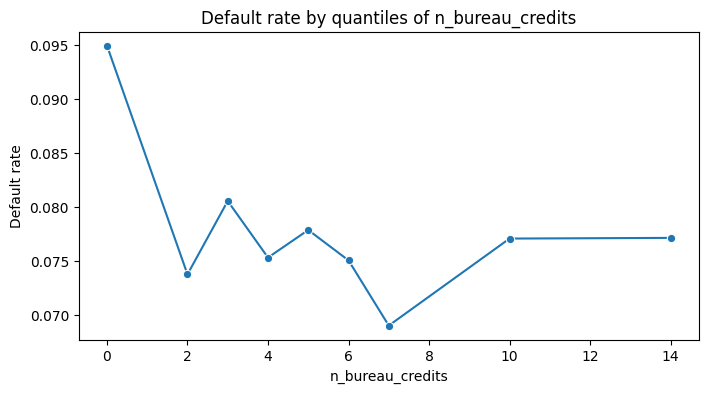

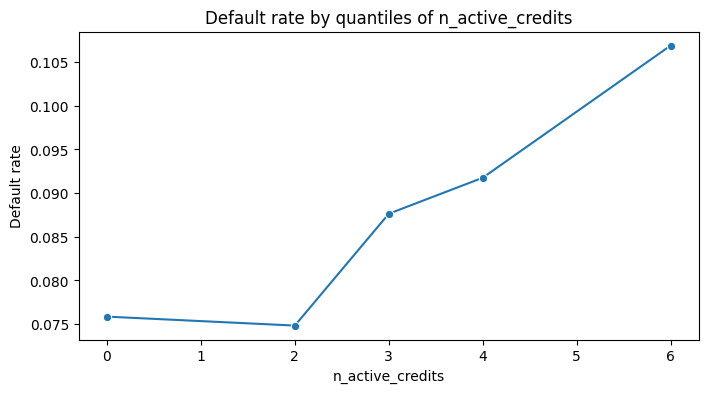

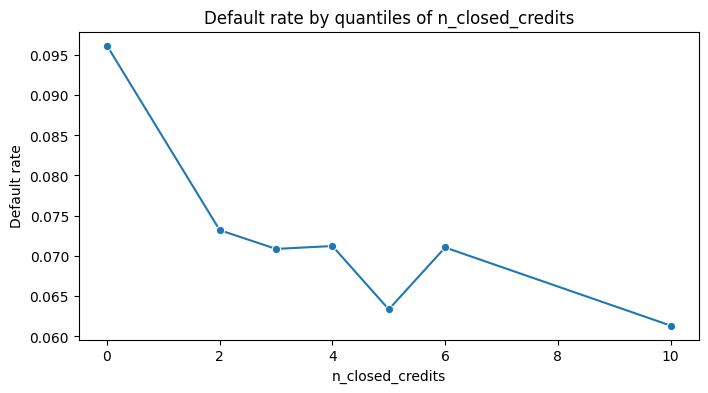

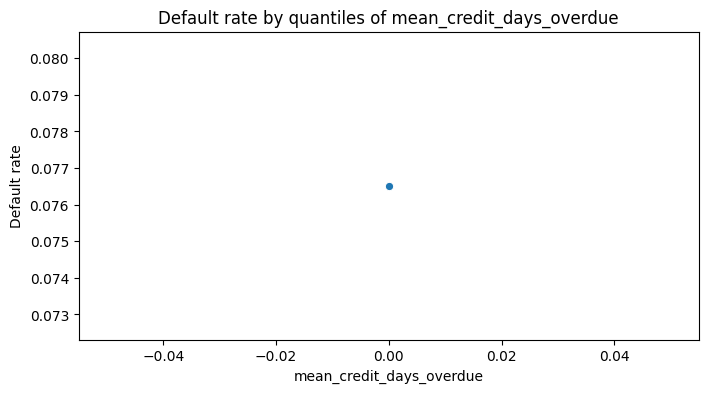

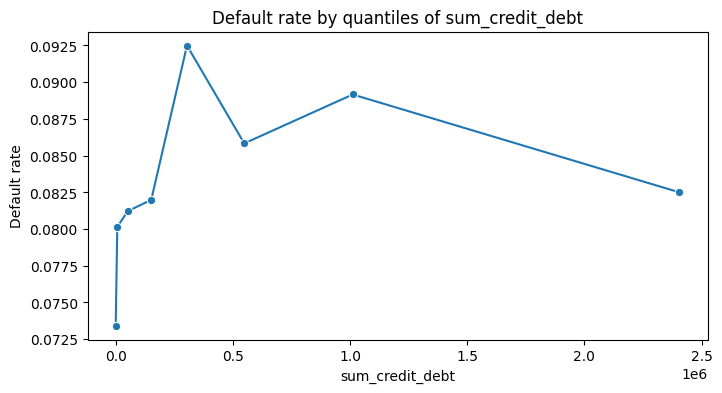

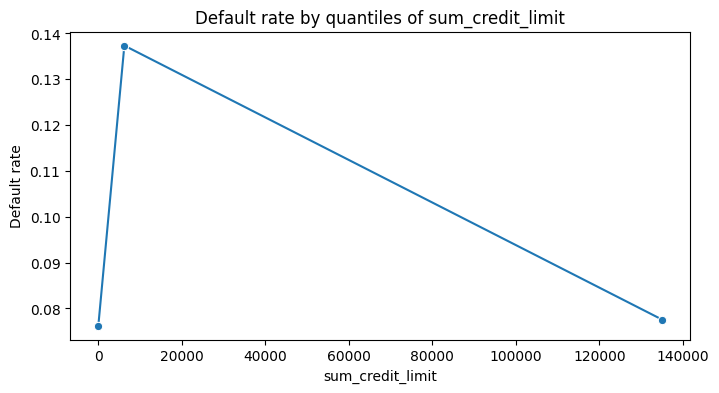

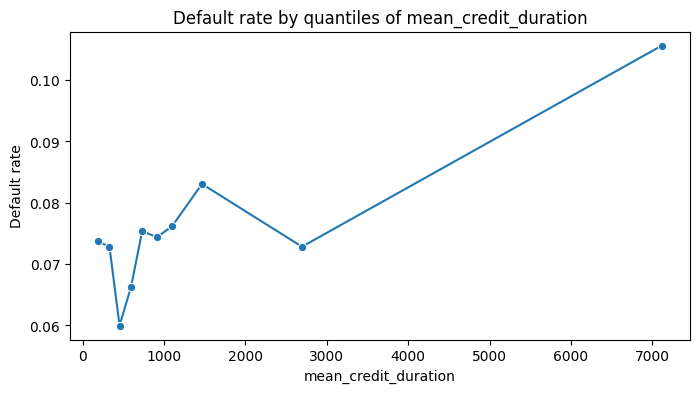

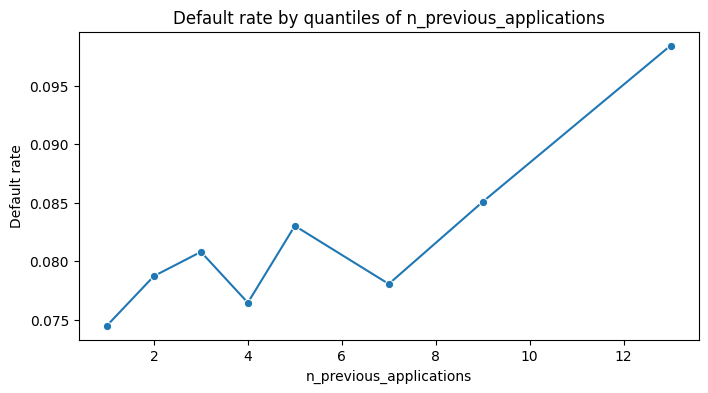

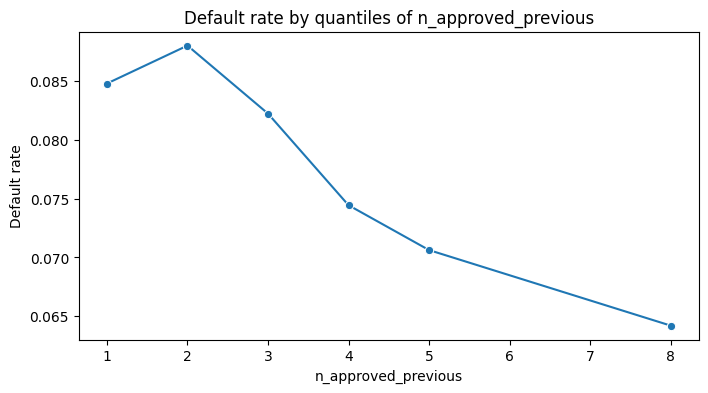

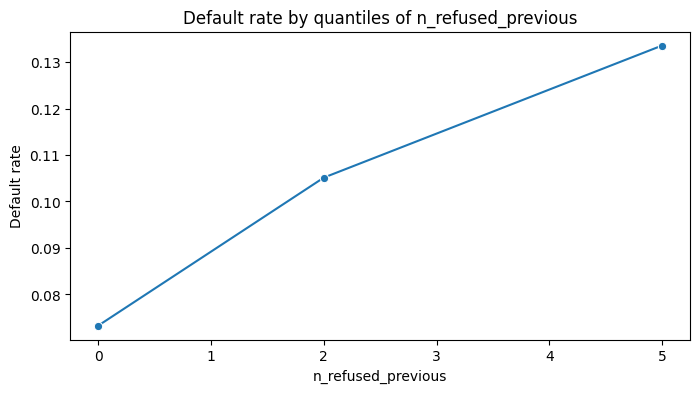

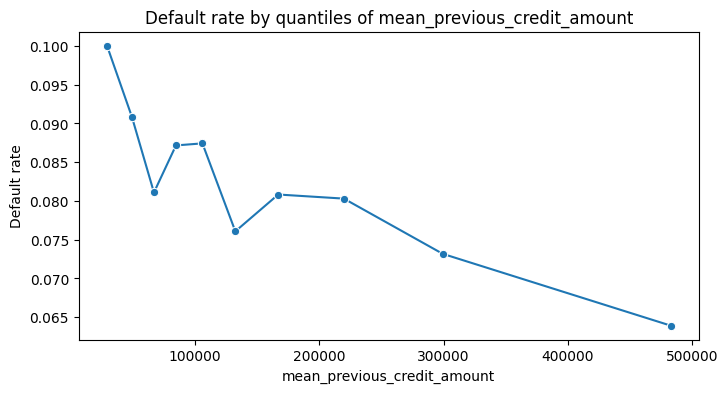

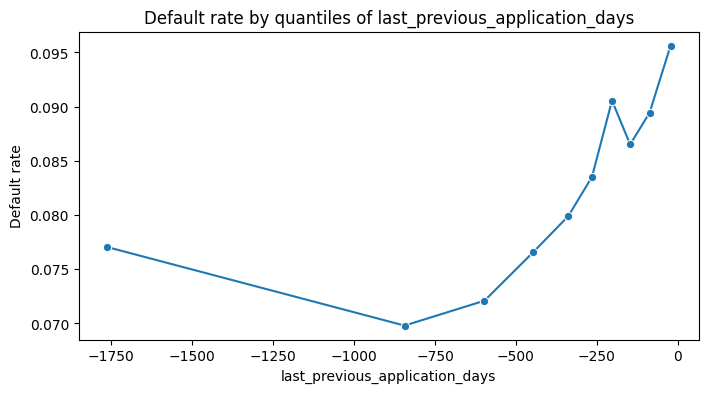

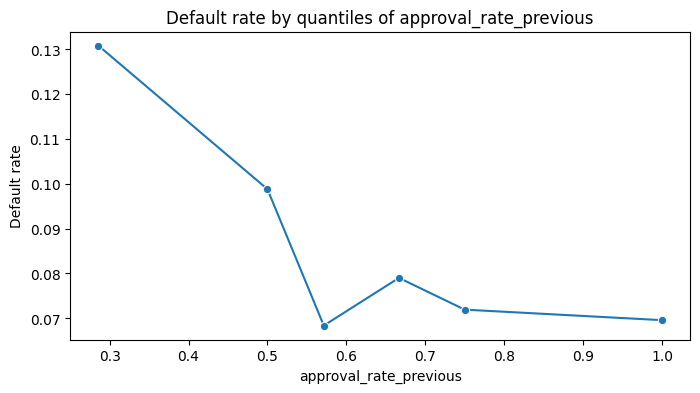

In [63]:
# =========================================================
# DEFAULT RATE BY QUANTILES OF HISTORICAL VARIABLES
# =========================================================

for col in history_num_variables:

    temp = df_train[[col, "TARGET"]].dropna().copy()

    if temp[col].nunique() > 1:

        temp["bin"] = pd.qcut(
            temp[col],
            q=10,
            duplicates="drop"
        )

        summary = (
            temp.groupby("bin", observed=True)
            .agg(
                default_rate=("TARGET", "mean"),
                n_obs=("TARGET", "size"),
                median_value=(col, "median")
            )
            .reset_index()
        )

        plt.figure(figsize=(8, 4))

        sns.lineplot(
            data=summary,
            x="median_value",
            y="default_rate",
            marker="o"
        )

        plt.title(f"Default rate by quantiles of {col}")
        plt.xlabel(col)
        plt.ylabel("Default rate")
        plt.show()

In [64]:
# =========================================================
# DEFAULT RATE BY CATEGORICAL VARIABLES
# =========================================================

for col in cat_variables:
    print(f"\nDefault rate by {col}")

    resumen = (
        df_train
        .groupby(col)["TARGET"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    resumen["TARGET"] = (resumen["TARGET"] * 100).round(2)

    display(resumen)


Default rate by CODE_GENDER


,CODE_GENDER,TARGET
0,M,10.17
1,F,6.99
2,XNA,0.00



Default rate by NAME_EDUCATION_TYPE


,NAME_EDUCATION_TYPE,TARGET
0,Lower secondary,12.04
1,Secondary / secondary special,8.94
2,Incomplete higher,7.83
3,Higher education,5.41
4,Academic degree,0.00



Default rate by NAME_INCOME_TYPE


,NAME_INCOME_TYPE,TARGET
0,Working,9.61
1,Commercial associate,7.40
2,State servant,5.64
3,Pensioner,5.53
4,Maternity leave,0.00
5,Businessman,0.00
6,Student,0.00
7,Unemployed,0.00



Default rate by NAME_FAMILY_STATUS


,NAME_FAMILY_STATUS,TARGET
0,Civil marriage,10.63
1,Single / not married,9.62
2,Separated,7.62
3,Married,7.51
4,Widow,6.45



Default rate by NAME_HOUSING_TYPE


,NAME_HOUSING_TYPE,TARGET
0,Rented apartment,12.72
1,With parents,11.64
2,Municipal apartment,8.46
3,House / apartment,7.80
4,Co-op apartment,6.96
5,Office apartment,6.34


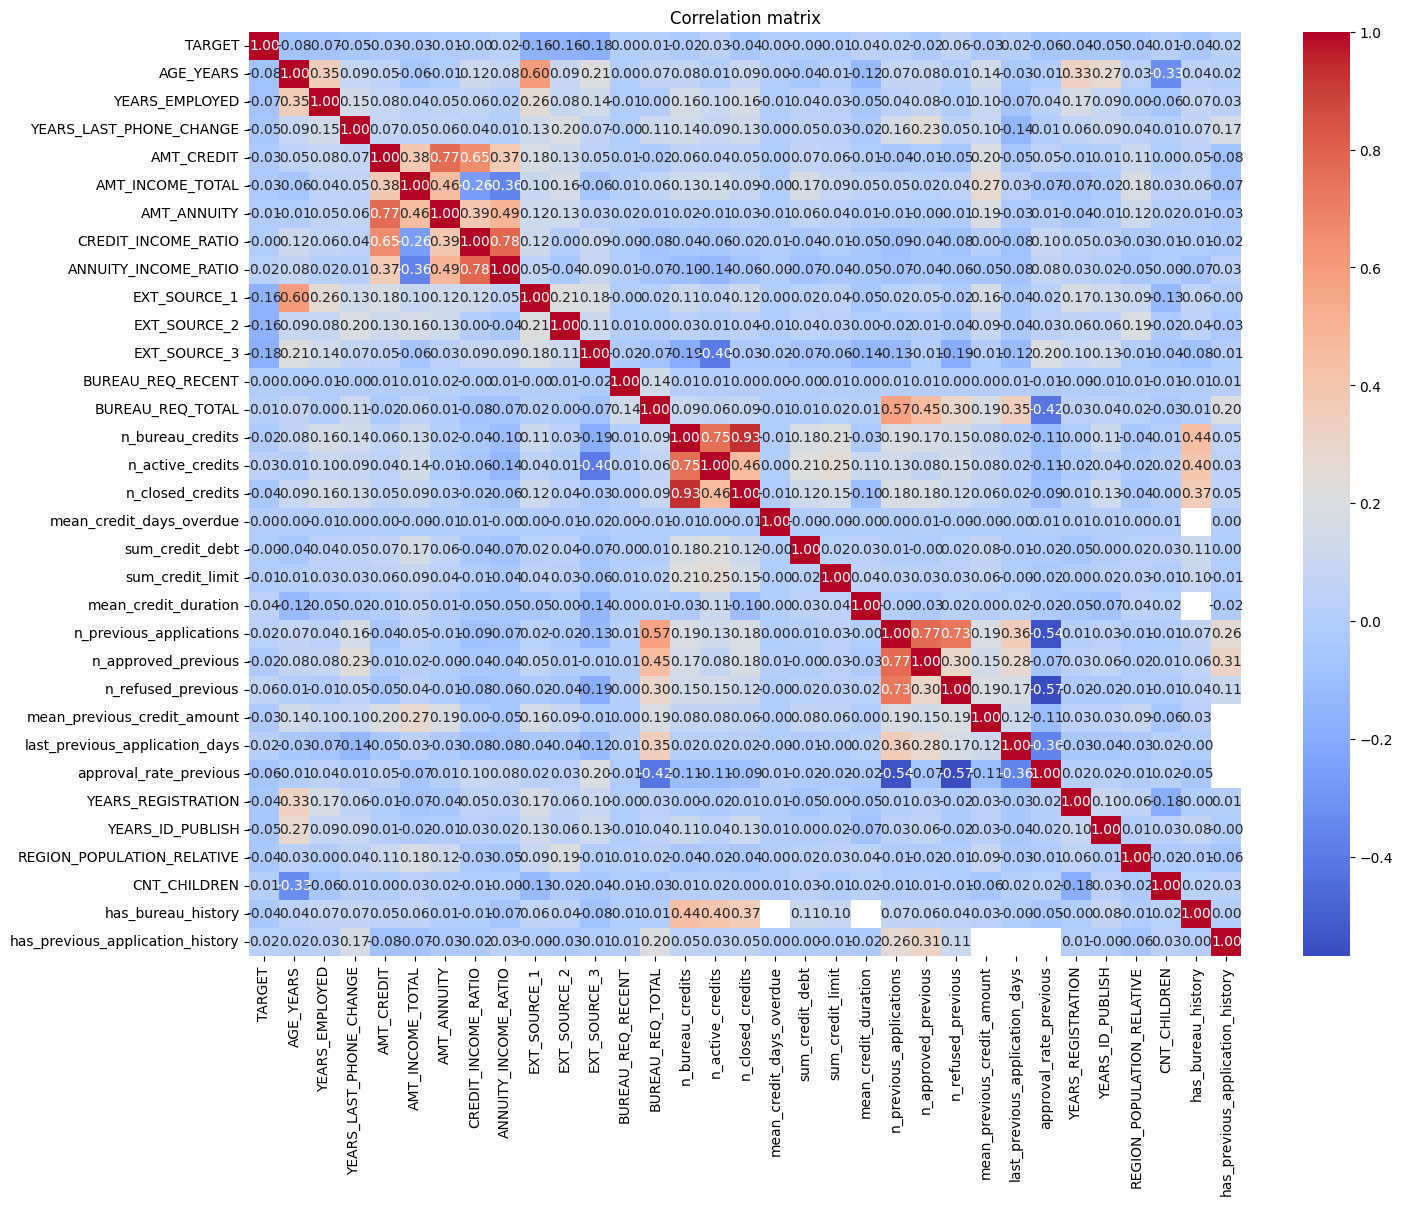

In [65]:
# =========================================================
# CORRELATION MATRIX FOR NUMERICAL VARIABLES
# =========================================================

num_corr_vars = [
    "TARGET",
    "AGE_YEARS",
    "YEARS_EMPLOYED",
    "YEARS_LAST_PHONE_CHANGE",
    "AMT_CREDIT",
    "AMT_INCOME_TOTAL",
    "AMT_ANNUITY",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "BUREAU_REQ_RECENT",
    "BUREAU_REQ_TOTAL",
    "DOCUMENT_COUNT",
    "n_bureau_credits",
    "n_active_credits",
    "n_closed_credits",
    "mean_credit_days_overdue",
    "sum_credit_debt",
    "sum_credit_limit",
    "mean_credit_duration",
    "n_previous_applications",
    "n_approved_previous",
    "n_refused_previous",
    "mean_previous_credit_amount",
    "last_previous_application_days",
    "approval_rate_previous",
    "YEARS_REGISTRATION",
    "YEARS_ID_PUBLISH",
    "REGION_POPULATION_RELATIVE",
    "CNT_CHILDREN",
    "has_bureau_history",
    "has_previous_application_history"
]

num_corr_vars = [col for col in num_corr_vars if col in df_train.columns]

corr = df_train[num_corr_vars].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

In [66]:
# =========================================================
# CORRELATION WITH TARGET
# =========================================================
corr_target = df1.corr(numeric_only=True)["TARGET"].drop("TARGET")

corr_target_df = (
    corr_target
    .sort_values()
    .reset_index()
    .rename(columns={
        "index": "variable",
        "TARGET": "correlation_with_target"
    })
)

corr_target_df

,variable,correlation_with_target
0,EXT_SOURCE_3,-0.178919
1,EXT_SOURCE_2,-0.160472
2,EXT_SOURCE_1,-0.155317
3,AGE_YEARS,-0.078239
4,YEARS_EMPLOYED,-0.074958
...,...,...
128,REGION_RATING_CLIENT,0.058899
129,REGION_RATING_CLIENT_W_CITY,0.060893
130,n_refused_previous,0.064756
131,DAYS_EMPLOYED_CLEAN,0.074958


In [67]:
# =========================================================
# DEFAULT RATE BY HISTORICAL COUNT VARIABLES
# =========================================================

history_count_variables = [
    "n_bureau_credits",
    "n_active_credits",
    "n_closed_credits",
    "n_previous_applications",
    "n_approved_previous",
    "n_refused_previous"
]

history_count_variables = [
    col for col in history_count_variables
    if col in df_train.columns
]

for col in history_count_variables:
    print(f"\nDefault rate by {col}")

    resumen = (
        df_train
        .groupby(col)["TARGET"]
        .agg(["mean", "count"])
        .sort_index()
        .reset_index()
    )

    resumen["mean"] = (resumen["mean"] * 100).round(2)
    resumen = resumen.rename(columns={
        "mean": "default_rate",
        "count": "n_obs"
    })

    display(resumen.head(20))


Default rate by n_bureau_credits


,n_bureau_credits,default_rate,n_obs
0,0.0,10.54,5825
1,1.0,8.21,4726
2,2.0,7.38,4664
3,3.0,8.06,4233
4,4.0,7.53,3678
5,5.0,7.79,3249
6,6.0,7.51,2838
7,7.0,6.80,2162
8,8.0,7.02,1881
9,9.0,7.97,1431



Default rate by n_active_credits


,n_active_credits,default_rate,n_obs
0,0.0,7.97,11837
1,1.0,7.10,9618
2,2.0,7.48,7526
3,3.0,8.76,4976
4,4.0,9.17,2834
5,5.0,10.10,1575
6,6.0,9.43,774
7,7.0,12.62,428
8,8.0,9.48,211
9,9.0,14.43,97



Default rate by n_closed_credits


...

,n_previous_applications,default_rate,n_obs
0,0.0,5.66,2138
1,1.0,8.01,6775
2,2.0,7.87,5881
3,3.0,8.08,5322
4,4.0,7.65,4251
5,5.0,8.23,3439
6,6.0,8.40,2680
7,7.0,7.81,2178
8,8.0,8.71,1710
9,9.0,8.10,1247



Default rate by n_approved_previous


,n_approved_previous,default_rate,n_obs
0,0.0,5.83,2263
1,1.0,9.08,9945
2,2.0,8.80,8738
3,3.0,8.22,6823
4,4.0,7.44,4662
5,5.0,7.14,2982
6,6.0,6.93,1861
7,7.0,4.92,1119
8,8.0,7.24,677
9,9.0,8.47,413



Default rate by n_refused_previous


,n_refused_previous,default_rate,n_obs
0,0.0,7.01,26853
1,1.0,8.75,6079
2,2.0,10.04,2988
3,3.0,11.43,1549
4,4.0,12.41,935
5,5.0,12.36,534
6,6.0,14.94,328
7,7.0,13.58,243
8,8.0,15.20,125
9,9.0,9.09,88


In [68]:
# =========================================================
# SELECTED VARIABLES FOR MODELING
# Reduced version to avoid redundant original/derived variables
# =========================================================

selected_features = [
    "TARGET",

    # Numerical variables from application_train
    "AGE_YEARS",
    "YEARS_EMPLOYED",
    "CNT_CHILDREN",
    "REGION_POPULATION_RELATIVE",


    # Financial ratio variables
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",

    # External risk scores
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",

    # Bureau request and document information
    "BUREAU_REQ_TOTAL",
    "DOCUMENT_COUNT",

    # Historical variables from bureau
    "n_bureau_credits",
    "n_active_credits",
    "mean_credit_days_overdue",
    "sum_credit_debt",
    "sum_credit_limit",
    "mean_credit_duration",

    # Binary history indicators
    "has_bureau_history",
    "has_previous_application_history",

    # Historical variables from previous_application
    "n_previous_applications",
    "mean_previous_credit_amount",
    "last_previous_application_days",
    "approval_rate_previous",
    "n_refused_previous",

    # Categorical variables
    "CODE_GENDER",
    "NAME_EDUCATION_TYPE",
    "NAME_INCOME_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]

selected_features = [col for col in selected_features if col in df_train.columns]

df_model = df_train[selected_features].copy()

df_model.head()

,TARGET,AGE_YEARS,YEARS_EMPLOYED,CNT_CHILDREN,REGION_POPULATION_RELATIVE,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,BUREAU_REQ_TOTAL,n_bureau_credits,n_active_credits,mean_credit_days_overdue,sum_credit_debt,sum_credit_limit,mean_credit_duration,has_bureau_history,has_previous_application_history,n_previous_applications,mean_previous_credit_amount,last_previous_application_days,approval_rate_previous,n_refused_previous,CODE_GENDER,NAME_EDUCATION_TYPE,NAME_INCOME_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,ORGANIZATION_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY
7692,0,39.542466,13.441096,0,0.028663,10.000000,0.292400,0.457668,0.722989,NaN,0.0,6.0,1.0,104.833333,8657.55,216342.45,632.833333,1,1,2.0,24282.000000,-276.0,1.000000,0.0,F,Secondary / secondary special,Working,Married,House / apartment,Private service staff,Self-employed,N,Y
6151,0,40.493151,0.476712,1,0.010006,2.198000,0.177360,NaN,0.149984,0.680139,1.0,9.0,3.0,0.000000,156937.50,194061.24,514.375000,1,1,2.0,20769.750000,-873.0,0.500000,1.0,F,Secondary / secondary special,State servant,Married,House / apartment,Medicine staff,Other,N,N
126947,0,51.090411,2.772603,1,0.010032,1.666667,0.143033,0.548045,0.084209,0.283712,3.0,4.0,2.0,0.000000,70245.00,0.00,343.333333,1,1,7.0,85609.285714,-49.0,0.428571,0.0,F,Secondary / secondary special,Working,Separated,House / apartment,NaN,Business Entity Type 3,N,N
100630,0,39.301370,1.673973,3,0.028663,4.285714,0.312686,NaN,0.604393,0.481249,5.0,7.0,3.0,0.000000,1131106.50,0.00,994.857143,1,1,5.0,233560.800000,-348.0,0.800000,0.0,F,Secondary / secondary special,Working,Married,House / apartment,Managers,Business Entity Type 3,N,Y
205306,0,64.841096,NaN,0,0.010500,3.370667,0.129000,NaN,0.578588,0.619528,5.0,13.0,2.0,0.000000,398484.00,0.00,584.076923,1,1,2.0,482913.000000,-237.0,1.000000,0.0,F,Secondary / secondary special,Pensioner,Married,House / apartment,NaN,XNA,N,Y


In [69]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40000 entries, 7692 to 239482
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   TARGET                            40000 non-null  int64  
 1   AGE_YEARS                         40000 non-null  float64
 2   YEARS_EMPLOYED                    32838 non-null  float64
 3   CNT_CHILDREN                      40000 non-null  int64  
 4   REGION_POPULATION_RELATIVE        40000 non-null  float64
 5   CREDIT_INCOME_RATIO               40000 non-null  float64
 6   ANNUITY_INCOME_RATIO              39997 non-null  float64
 7   EXT_SOURCE_1                      17467 non-null  float64
 8   EXT_SOURCE_2                      39917 non-null  float64
 9   EXT_SOURCE_3                      32000 non-null  float64
 10  BUREAU_REQ_TOTAL                  34532 non-null  float64
 11  n_bureau_credits                  40000 non-null  float64
 12  n_act

In [70]:
# Missing values in selected variables

df_model.isna().sum().sort_values(ascending=False)

,0
EXT_SOURCE_1,22533
OCCUPATION_TYPE,12561
EXT_SOURCE_3,8000
YEARS_EMPLOYED,7162
mean_credit_duration,6114
mean_credit_days_overdue,5825
BUREAU_REQ_TOTAL,5468
sum_credit_limit,2750
last_previous_application_days,2138
mean_previous_credit_amount,2138


In [71]:
# =========================================================
# GROUPING SELECTED VARIABLES FOR MODELING
# =========================================================

df_model_grouped = df_model.copy()

df_model_grouped.head()

,TARGET,AGE_YEARS,YEARS_EMPLOYED,CNT_CHILDREN,REGION_POPULATION_RELATIVE,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,BUREAU_REQ_TOTAL,n_bureau_credits,n_active_credits,mean_credit_days_overdue,sum_credit_debt,sum_credit_limit,mean_credit_duration,has_bureau_history,has_previous_application_history,n_previous_applications,mean_previous_credit_amount,last_previous_application_days,approval_rate_previous,n_refused_previous,CODE_GENDER,NAME_EDUCATION_TYPE,NAME_INCOME_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,ORGANIZATION_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY
7692,0,39.542466,13.441096,0,0.028663,10.000000,0.292400,0.457668,0.722989,NaN,0.0,6.0,1.0,104.833333,8657.55,216342.45,632.833333,1,1,2.0,24282.000000,-276.0,1.000000,0.0,F,Secondary / secondary special,Working,Married,House / apartment,Private service staff,Self-employed,N,Y
6151,0,40.493151,0.476712,1,0.010006,2.198000,0.177360,NaN,0.149984,0.680139,1.0,9.0,3.0,0.000000,156937.50,194061.24,514.375000,1,1,2.0,20769.750000,-873.0,0.500000,1.0,F,Secondary / secondary special,State servant,Married,House / apartment,Medicine staff,Other,N,N
126947,0,51.090411,2.772603,1,0.010032,1.666667,0.143033,0.548045,0.084209,0.283712,3.0,4.0,2.0,0.000000,70245.00,0.00,343.333333,1,1,7.0,85609.285714,-49.0,0.428571,0.0,F,Secondary / secondary special,Working,Separated,House / apartment,NaN,Business Entity Type 3,N,N
100630,0,39.301370,1.673973,3,0.028663,4.285714,0.312686,NaN,0.604393,0.481249,5.0,7.0,3.0,0.000000,1131106.50,0.00,994.857143,1,1,5.0,233560.800000,-348.0,0.800000,0.0,F,Secondary / secondary special,Working,Married,House / apartment,Managers,Business Entity Type 3,N,Y
205306,0,64.841096,NaN,0,0.010500,3.370667,0.129000,NaN,0.578588,0.619528,5.0,13.0,2.0,0.000000,398484.00,0.00,584.076923,1,1,2.0,482913.000000,-237.0,1.000000,0.0,F,Secondary / secondary special,Pensioner,Married,House / apartment,NaN,XNA,N,Y


In [72]:
# Grouping count variables if they are available in df_model

if "CNT_CHILDREN" in df_model_grouped.columns:
    df_model_grouped["CNT_CHILDREN_GROUP"] = pd.cut(
        df_model_grouped["CNT_CHILDREN"],
        bins=[-1, 0, 1, 2, np.inf],
        labels=["0", "1", "2", "3+"]
    ).astype("object")

if "BUREAU_REQ_TOTAL" in df_model_grouped.columns:
    df_model_grouped["BUREAU_REQ_TOTAL_GROUP"] = pd.cut(
        df_model_grouped["BUREAU_REQ_TOTAL"],
        bins=[-1, 0, 1, 3, np.inf],
        labels=["0", "1", "2-3", "4+"]
    ).astype("object")

if "n_bureau_credits" in df_model_grouped.columns:
    df_model_grouped["n_bureau_credits_GROUP"] = pd.cut(
        df_model_grouped["n_bureau_credits"],
        bins=[-1, 0, 1, 3, np.inf],
        labels=["0", "1", "2-3", "4+"]
    ).astype("object")

if "n_active_credits" in df_model_grouped.columns:
    df_model_grouped["n_active_credits_GROUP"] = pd.cut(
        df_model_grouped["n_active_credits"],
        bins=[-1, 0, 1, 3, np.inf],
        labels=["0", "1", "2-3", "4+"]
    ).astype("object")

if "n_previous_applications" in df_model_grouped.columns:
    df_model_grouped["n_previous_applications_GROUP"] = pd.cut(
        df_model_grouped["n_previous_applications"],
        bins=[-1, 0, 1, 3, np.inf],
        labels=["0", "1", "2-3" , "4+"]
    ).astype("object")

if "n_refused_previous" in df_model_grouped.columns:
    df_model_grouped["n_refused_previous_GROUP"] = pd.cut(
        df_model_grouped["n_refused_previous"],
        bins=[-1, 0, 1, np.inf],
        labels=["0", "1", "2+"]
    ).astype("object")

In [73]:
# Grouping education categories if available

if "NAME_EDUCATION_TYPE" in df_model_grouped.columns:
    df_model_grouped["NAME_EDUCATION_TYPE_GROUP"] = df_model_grouped["NAME_EDUCATION_TYPE"].replace({
        "Academic degree": "Higher education / Academic degree",
        "Higher education": "Higher education / Academic degree"
    })

df_model_grouped.head()

,TARGET,AGE_YEARS,YEARS_EMPLOYED,CNT_CHILDREN,REGION_POPULATION_RELATIVE,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,BUREAU_REQ_TOTAL,n_bureau_credits,n_active_credits,mean_credit_days_overdue,sum_credit_debt,sum_credit_limit,mean_credit_duration,has_bureau_history,has_previous_application_history,n_previous_applications,mean_previous_credit_amount,last_previous_application_days,approval_rate_previous,n_refused_previous,CODE_GENDER,NAME_EDUCATION_TYPE,NAME_INCOME_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,ORGANIZATION_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN_GROUP,BUREAU_REQ_TOTAL_GROUP,n_bureau_credits_GROUP,n_active_credits_GROUP,n_previous_applications_GROUP,n_refused_previous_GROUP,NAME_EDUCATION_TYPE_GROUP
7692,0,39.542466,13.441096,0,0.028663,10.000000,0.292400,0.457668,0.722989,NaN,0.0,6.0,1.0,104.833333,8657.55,216342.45,632.833333,1,1,2.0,24282.000000,-276.0,1.000000,0.0,F,Secondary / secondary special,Working,Married,House / apartment,Private service staff,Self-employed,N,Y,0,0,4+,1,2-3,0,Secondary / secondary special
6151,0,40.493151,0.476712,1,0.010006,2.198000,0.177360,NaN,0.149984,0.680139,1.0,9.0,3.0,0.000000,156937.50,194061.24,514.375000,1,1,2.0,20769.750000,-873.0,0.500000,1.0,F,Secondary / secondary special,State servant,Married,House / apartment,Medicine staff,Other,N,N,1,1,4+,2-3,2-3,1,Secondary / secondary special
126947,0,51.090411,2.772603,1,0.010032,1.666667,0.143033,0.548045,0.084209,0.283712,3.0,4.0,2.0,0.000000,70245.00,0.00,343.333333,1,1,7.0,85609.285714,-49.0,0.428571,0.0,F,Secondary / secondary special,Working,Separated,House / apartment,NaN,Business Entity Type 3,N,N,1,2-3,4+,2-3,4+,0,Secondary / secondary special
100630,0,39.301370,1.673973,3,0.028663,4.285714,0.312686,NaN,0.604393,0.481249,5.0,7.0,3.0,0.000000,1131106.50,0.00,994.857143,1,1,5.0,233560.800000,-348.0,0.800000,0.0,F,Secondary / secondary special,Working,Married,House / apartment,Managers,Business Entity Type 3,N,Y,3+,4+,4+,2-3,4+,0,Secondary / secondary special
205306,0,64.841096,NaN,0,0.010500,3.370667,0.129000,NaN,0.578588,0.619528,5.0,13.0,2.0,0.000000,398484.00,0.00,584.076923,1,1,2.0,482913.000000,-237.0,1.000000,0.0,F,Secondary / secondary special,Pensioner,Married,House / apartment,NaN,XNA,N,Y,0,4+,4+,2-3,2-3,0,Secondary / secondary special


In [74]:
# Checking new grouped variables

grouped_cols = [
    col for col in df_model_grouped.columns
    if col.endswith("_GROUP")
]

grouped_cols

['CNT_CHILDREN_GROUP',
 'BUREAU_REQ_TOTAL_GROUP',
 'n_bureau_credits_GROUP',
 'n_active_credits_GROUP',
 'n_previous_applications_GROUP',
 'n_refused_previous_GROUP',
 'NAME_EDUCATION_TYPE_GROUP']

In [75]:
for col in grouped_cols:
    print(f"\n{col}")
    print(df_model_grouped[col].value_counts(dropna=False))


CNT_CHILDREN_GROUP
CNT_CHILDREN_GROUP
0     27978
1      7972
2      3476
3+      574
Name: count, dtype: int64

BUREAU_REQ_TOTAL_GROUP
BUREAU_REQ_TOTAL_GROUP
2-3    11763
4+      9133
1       7045
0       6591
NaN     5468
Name: count, dtype: int64

n_bureau_credits_GROUP
n_bureau_credits_GROUP
4+     20552
2-3     8897
0       5825
1       4726
Name: count, dtype: int64

n_active_credits_GROUP
n_active_credits_GROUP
2-3    12502
0      11837
1       9618
4+      6043
Name: count, dtype: int64

n_previous_applications_GROUP
n_previous_applications_GROUP
4+     19884
2-3    11203
1       6775
0       2138
Name: count, dtype: int64

n_refused_previous_GROUP
n_refused_previous_GROUP
0     26853
2+     7068
1      6079
Name: count, dtype: int64

NAME_EDUCATION_TYPE_GROUP
NAME_EDUCATION_TYPE_GROUP
Secondary / secondary special         28330
Higher education / Academic degree     9788
Incomplete higher                      1392
Lower secondary                         490
Name: count, dtype

In [76]:
# =========================================================
# FINAL VARIABLES FOR GROUPED MODEL
# =========================================================

final_grouped_features = [
    "TARGET",

    # Numerical variables from application_train
    "AGE_YEARS",
    "YEARS_EMPLOYED",
    "REGION_POPULATION_RELATIVE",

    # Grouped count variables
    "CNT_CHILDREN_GROUP",
    "BUREAU_REQ_TOTAL_GROUP",

    # Financial ratio variables
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",

    # External risk scores
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",

    # Historical variables from bureau
    "mean_credit_days_overdue",
    "sum_credit_debt",
    "sum_credit_limit",
    "mean_credit_duration",

    # Grouped historical count variables
    "n_bureau_credits_GROUP",
    "n_active_credits_GROUP",


    # Binary history indicators
    "has_bureau_history",
    "has_previous_application_history",

    # Historical variables from previous_application
    "mean_previous_credit_amount",
    "last_previous_application_days",
    "approval_rate_previous",

    # Grouped previous application count variables
    "n_previous_applications_GROUP",
    "n_refused_previous_GROUP",

    # Categorical variables
    "CODE_GENDER",
    "NAME_EDUCATION_TYPE_GROUP",
    "NAME_INCOME_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]

final_grouped_features = [
    col for col in final_grouped_features
    if col in df_model_grouped.columns
]

df_model_grouped = df_model_grouped[final_grouped_features].copy()

df_model_grouped.head()

,TARGET,AGE_YEARS,YEARS_EMPLOYED,REGION_POPULATION_RELATIVE,CNT_CHILDREN_GROUP,BUREAU_REQ_TOTAL_GROUP,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,mean_credit_days_overdue,sum_credit_debt,sum_credit_limit,mean_credit_duration,n_bureau_credits_GROUP,n_active_credits_GROUP,has_bureau_history,has_previous_application_history,mean_previous_credit_amount,last_previous_application_days,approval_rate_previous,n_previous_applications_GROUP,n_refused_previous_GROUP,CODE_GENDER,NAME_EDUCATION_TYPE_GROUP,NAME_INCOME_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,ORGANIZATION_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY
7692,0,39.542466,13.441096,0.028663,0,0,10.000000,0.292400,0.457668,0.722989,NaN,104.833333,8657.55,216342.45,632.833333,4+,1,1,1,24282.000000,-276.0,1.000000,2-3,0,F,Secondary / secondary special,Working,Married,House / apartment,Private service staff,Self-employed,N,Y
6151,0,40.493151,0.476712,0.010006,1,1,2.198000,0.177360,NaN,0.149984,0.680139,0.000000,156937.50,194061.24,514.375000,4+,2-3,1,1,20769.750000,-873.0,0.500000,2-3,1,F,Secondary / secondary special,State servant,Married,House / apartment,Medicine staff,Other,N,N
126947,0,51.090411,2.772603,0.010032,1,2-3,1.666667,0.143033,0.548045,0.084209,0.283712,0.000000,70245.00,0.00,343.333333,4+,2-3,1,1,85609.285714,-49.0,0.428571,4+,0,F,Secondary / secondary special,Working,Separated,House / apartment,NaN,Business Entity Type 3,N,N
100630,0,39.301370,1.673973,0.028663,3+,4+,4.285714,0.312686,NaN,0.604393,0.481249,0.000000,1131106.50,0.00,994.857143,4+,2-3,1,1,233560.800000,-348.0,0.800000,4+,0,F,Secondary / secondary special,Working,Married,House / apartment,Managers,Business Entity Type 3,N,Y
205306,0,64.841096,NaN,0.010500,0,4+,3.370667,0.129000,NaN,0.578588,0.619528,0.000000,398484.00,0.00,584.076923,4+,2-3,1,1,482913.000000,-237.0,1.000000,2-3,0,F,Secondary / secondary special,Pensioner,Married,House / apartment,NaN,XNA,N,Y


In [77]:
df_model_grouped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40000 entries, 7692 to 239482
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   TARGET                            40000 non-null  int64  
 1   AGE_YEARS                         40000 non-null  float64
 2   YEARS_EMPLOYED                    32838 non-null  float64
 3   REGION_POPULATION_RELATIVE        40000 non-null  float64
 4   CNT_CHILDREN_GROUP                40000 non-null  object 
 5   BUREAU_REQ_TOTAL_GROUP            34532 non-null  object 
 6   CREDIT_INCOME_RATIO               40000 non-null  float64
 7   ANNUITY_INCOME_RATIO              39997 non-null  float64
 8   EXT_SOURCE_1                      17467 non-null  float64
 9   EXT_SOURCE_2                      39917 non-null  float64
 10  EXT_SOURCE_3                      32000 non-null  float64
 11  mean_credit_days_overdue          34175 non-null  float64
 12  sum_c

In [78]:
# =========================================================
# SEPARATING FEATURES AND TARGET
# =========================================================

X = df_model_grouped.drop("TARGET", axis=1)
y = df_model_grouped["TARGET"]

print(X.shape)
print(y.shape)

(40000, 32)
(40000,)


In [79]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [80]:
# Cross-validation configuration

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [81]:
# =========================================================
# CROSS-VALIDATION WITH RANDOM FOREST
# =========================================================

# The preprocessing steps are applied inside each fold to avoid data leakage.
# Missing indicators are created before imputation to preserve missingness information.
# Numerical values are imputed using the median from X_train only.
# Categorical values are imputed using the mode from X_train only.
# Rare category grouping is learned only from X_train and then applied to X_valid.

rf_results = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):

    print(f"\nFold {fold}")

    X_train = X.iloc[train_idx].copy()
    X_valid = X.iloc[valid_idx].copy()

    y_train = y.iloc[train_idx].copy()
    y_valid = y.iloc[valid_idx].copy()

    # Separating numerical and categorical variables
    num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
    cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

    # Missing indicators for numerical variables
    # The decision to create each indicator is based only on X_train.
    for col in num_cols:
        if X_train[col].isna().sum() > 0:
            X_train[col + "_missing"] = X_train[col].isna().astype(int)
            X_valid[col + "_missing"] = X_valid[col].isna().astype(int)

    # Missing value treatment for numerical variables
    # The median is calculated only with X_train.
    for col in num_cols:
        median_value = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_value)
        X_valid[col] = X_valid[col].fillna(median_value)

# Numerical missing values are imputed with the median, after creating missing indicators to preserve the information that the value was absent.
# Categorical missing values are treated as an explicit "Missing" category, which is later converted into dummy variables.
    for col in cat_cols:
          X_train[col] = X_train[col].fillna("Missing")
          X_valid[col] = X_valid[col].fillna("Missing")

    # Grouping rare categories
    # Categories with frequency below 1% are replaced by "Other".
    # The rule is learned only from the training fold and then applied to validation.
    for col in cat_cols:
        freq = X_train[col].value_counts(normalize=True)

        common_categories = freq[freq >= 0.01].index

        X_train[col] = X_train[col].where(
            X_train[col].isin(common_categories),
            "Other"
        )

        X_valid[col] = X_valid[col].where(
            X_valid[col].isin(common_categories),
            "Other"
        )

    # Generating dummy variables inside each fold
    X_train = pd.get_dummies(X_train, drop_first=False)
    X_valid = pd.get_dummies(X_valid, drop_first=False)

    # Aligning train and validation columns
    # Validation columns not learned from training are removed.
    # Training columns missing in validation are filled with 0.
    X_train, X_valid = X_train.align(
        X_valid,
        join="left",
        axis=1,
        fill_value=0
    )

    # Random Forest model
    rf_model = RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_valid)
    y_proba = rf_model.predict_proba(X_valid)[:, 1]

    fold_result = {
        "fold": fold,
        "accuracy": accuracy_score(y_valid, y_pred),
        "precision": precision_score(y_valid, y_pred, zero_division=0),
        "recall": recall_score(y_valid, y_pred, zero_division=0),
        "f1": f1_score(y_valid, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_valid, y_proba),
        "pr_auc": average_precision_score(y_valid, y_proba)
    }

    rf_results.append(fold_result)

    print(fold_result)


Fold 1
{'fold': 1, 'accuracy': 0.7795, 'precision': 0.19173553719008266, 'recall': 0.5395348837209303, 'f1': 0.28292682926829266, 'roc_auc': np.float64(0.7362589389699566), 'pr_auc': np.float64(0.21864372300424728)}

Fold 2
{'fold': 2, 'accuracy': 0.778375, 'precision': 0.19089413055403182, 'recall': 0.5386996904024768, 'f1': 0.2818955042527339, 'roc_auc': np.float64(0.7427023140246751), 'pr_auc': np.float64(0.21831318393542795)}

Fold 3
{'fold': 3, 'accuracy': 0.783125, 'precision': 0.1915014164305949, 'recall': 0.5232198142414861, 'f1': 0.28038158440481126, 'roc_auc': np.float64(0.7409991908533593), 'pr_auc': np.float64(0.21758513771594476)}

Fold 4
{'fold': 4, 'accuracy': 0.78125, 'precision': 0.19023569023569023, 'recall': 0.5247678018575851, 'f1': 0.27924217462932455, 'roc_auc': np.float64(0.7416136286901002), 'pr_auc': np.float64(0.20741693501975061)}

Fold 5
{'fold': 5, 'accuracy': 0.784375, 'precision': 0.1925925925925926, 'recall': 0.5232198142414861, 'f1': 0.2815493544356518

In [82]:
# Random Forest cross-validation results

rf_results_df = pd.DataFrame(rf_results)

rf_results_df

,fold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,1,0.779500,0.191736,0.539535,0.282927,0.736259,0.218644
1,2,0.778375,0.190894,0.538700,0.281896,0.742702,0.218313
2,3,0.783125,0.191501,0.523220,0.280382,0.740999,0.217585
3,4,0.781250,0.190236,0.524768,0.279242,0.741614,0.207417
4,5,0.784375,0.192593,0.523220,0.281549,0.738150,0.216782


In [83]:
# Mean performance

rf_results_df.mean(numeric_only=True)

,0
fold,3.000000
accuracy,0.781325
precision,0.191392
recall,0.529888
f1,0.281199
roc_auc,0.739945
pr_auc,0.215748


In [84]:
# Standard deviation

rf_results_df.std(numeric_only=True)

,0
fold,1.581139
accuracy,0.002479
precision,0.000888
recall,0.008454
f1,0.001422
roc_auc,0.002660
pr_auc,0.004712


In [85]:
# =========================================================
# CROSS-VALIDATION WITH XGBOOST
# =========================================================

# The same grouped dataframe is used for XGBoost.
# The preprocessing steps are again applied inside each fold to avoid data leakage.

xgb_results = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):

    print(f"\nFold {fold}")

    X_train = X.iloc[train_idx].copy()
    X_valid = X.iloc[valid_idx].copy()

    y_train = y.iloc[train_idx].copy()
    y_valid = y.iloc[valid_idx].copy()

    # Separating numerical and categorical variables
    num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
    cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

    # Missing indicators for numerical variables
    # The decision to create each indicator is based only on X_train.
    for col in num_cols:
        if X_train[col].isna().sum() > 0:
            X_train[col + "_missing"] = X_train[col].isna().astype(int)
            X_valid[col + "_missing"] = X_valid[col].isna().astype(int)

    # Missing value treatment for numerical variables
    # The median is calculated only with X_train.
    for col in num_cols:
        median_value = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_value)
        X_valid[col] = X_valid[col].fillna(median_value)


    # Numerical missing values are imputed with the median, after creating missing indicators to preserve the information that the value was absent.
    # Categorical missing values are treated as an explicit "Missing" category, which is later converted into dummy variables.
    for col in cat_cols:
          X_train[col] = X_train[col].fillna("Missing")
          X_valid[col] = X_valid[col].fillna("Missing")

    # Grouping rare categories
    # Categories with frequency below 1% are replaced by "Other".
    # The rule is learned only from the training fold and then applied to validation.
    for col in cat_cols:
        freq = X_train[col].value_counts(normalize=True)

        common_categories = freq[freq >= 0.01].index

        X_train[col] = X_train[col].where(
            X_train[col].isin(common_categories),
            "Other"
        )

        X_valid[col] = X_valid[col].where(
            X_valid[col].isin(common_categories),
            "Other"
        )

    # Generating dummy variables inside each fold
    X_train = pd.get_dummies(X_train, drop_first=False)
    X_valid = pd.get_dummies(X_valid, drop_first=False)

    # Aligning train and validation columns
    # Validation columns not learned from training are removed.
    # Training columns missing in validation are filled with 0.
    X_train, X_valid = X_train.align(
        X_valid,
        join="left",
        axis=1,
        fill_value=0
    )

    # Weight for imbalanced target
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    # XGBoost model
    xgb_model = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
        random_state=42,
        n_jobs=-1
    )

    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_valid)
    y_proba = xgb_model.predict_proba(X_valid)[:, 1]

    fold_result = {
        "fold": fold,
        "accuracy": accuracy_score(y_valid, y_pred),
        "precision": precision_score(y_valid, y_pred, zero_division=0),
        "recall": recall_score(y_valid, y_pred),
        "f1": f1_score(y_valid, y_pred),
        "roc_auc": roc_auc_score(y_valid, y_proba),
        "pr_auc": average_precision_score(y_valid, y_proba)
    }

    xgb_results.append(fold_result)

    print(fold_result)


Fold 1
{'fold': 1, 'accuracy': 0.707875, 'precision': 0.16640378548895898, 'recall': 0.6542635658914728, 'f1': 0.2653253693806979, 'roc_auc': np.float64(0.741228611027672), 'pr_auc': np.float64(0.22877516992866334)}

Fold 2
{'fold': 2, 'accuracy': 0.7095, 'precision': 0.16968503937007873, 'recall': 0.6671826625386997, 'f1': 0.27055869428750784, 'roc_auc': np.float64(0.7486909253488552), 'pr_auc': np.float64(0.23717423589316303)}

Fold 3
{'fold': 3, 'accuracy': 0.7115, 'precision': 0.16892430278884463, 'recall': 0.6563467492260062, 'f1': 0.26869455006337134, 'roc_auc': np.float64(0.7418771696875649), 'pr_auc': np.float64(0.22156274776323082)}

Fold 4
{'fold': 4, 'accuracy': 0.70525, 'precision': 0.16483946750195771, 'recall': 0.651702786377709, 'f1': 0.263125, 'roc_auc': np.float64(0.7482806686363478), 'pr_auc': np.float64(0.22373127745994437)}

Fold 5
{'fold': 5, 'accuracy': 0.707625, 'precision': 0.1652827204428628, 'recall': 0.6470588235294118, 'f1': 0.26330708661417324, 'roc_auc': 

In [ ]:
# XGBoost cross-validation results

xgb_results_df = pd.DataFrame(xgb_results)

xgb_results_df

In [ ]:
# Mean performance

xgb_results_df.mean(numeric_only=True)

In [88]:
# Standard deviation

xgb_results_df.std(numeric_only=True)

,0
fold,1.581139
accuracy,0.002324
precision,0.002173
recall,0.007487
f1,0.003309
roc_auc,0.005410
pr_auc,0.006056


In [89]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [90]:
# =========================================================
# CROSS-VALIDATION WITH LOGISTIC REGRESSION - RIDGE PENALTY
# =========================================================

# The preprocessing steps are applied inside each fold to avoid data leakage.
# Missing indicators are created before imputation to preserve missingness information.
# Numerical values are imputed using the median from X_train only.
# Categorical values are imputed using the mode from X_train only.
# Rare category grouping is learned only from X_train and then applied to X_valid.
# Numerical variables are scaled using parameters learned only from X_train.

ridge_results = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):

    print(f"\nFold {fold}")

    X_train = X.iloc[train_idx].copy()
    X_valid = X.iloc[valid_idx].copy()

    y_train = y.iloc[train_idx].copy()
    y_valid = y.iloc[valid_idx].copy()

    # Separating numerical and categorical variables
    num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
    cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

    # Missing indicators for numerical variables
    # The decision to create each indicator is based only on X_train.
    for col in num_cols:
        if X_train[col].isna().sum() > 0:
            X_train[col + "_missing"] = X_train[col].isna().astype(int)
            X_valid[col + "_missing"] = X_valid[col].isna().astype(int)

    # Updating numerical columns after creating missing indicators
    num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

    # Missing value treatment for numerical variables
    # The median is calculated only with X_train.
    for col in num_cols:
        median_value = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_value)
        X_valid[col] = X_valid[col].fillna(median_value)


    # Categorical missing values are treated as an explicit "Missing" category.
    for col in cat_cols:
        X_train[col] = X_train[col].fillna("Missing")
        X_valid[col] = X_valid[col].fillna("Missing")

    # Grouping rare categories
    # Categories with frequency below 1% are replaced by "Other".
    # The rule is learned only from the training fold and then applied to validation.
    for col in cat_cols:
        freq = X_train[col].value_counts(normalize=True)

        common_categories = freq[freq >= 0.01].index

        X_train[col] = X_train[col].where(
            X_train[col].isin(common_categories),
            "Other"
        )

        X_valid[col] = X_valid[col].where(
            X_valid[col].isin(common_categories),
            "Other"
        )

    # Scaling numerical variables
    # The scaler is fitted only with X_train.
    scaler = StandardScaler()

    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_valid[num_cols] = scaler.transform(X_valid[num_cols])

    # Generating dummy variables inside the fold
    # For Logistic Regression, drop_first=True avoids redundant dummy variables.
    X_train = pd.get_dummies(X_train, drop_first=True)
    X_valid = pd.get_dummies(X_valid, drop_first=True)

    # Aligning train and validation columns
    # Validation columns not learned from training are removed.
    # Training columns missing in validation are filled with 0.
    X_train, X_valid = X_train.align(
        X_valid,
        join="left",
        axis=1,
        fill_value=0
    )

    # Logistic Regression model with Ridge penalty
    ridge_model = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="saga",
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )

    ridge_model.fit(X_train, y_train)

    y_pred = ridge_model.predict(X_valid)
    y_proba = ridge_model.predict_proba(X_valid)[:, 1]

    fold_result = {
        "fold": fold,
        "accuracy": accuracy_score(y_valid, y_pred),
        "precision": precision_score(y_valid, y_pred, zero_division=0),
        "recall": recall_score(y_valid, y_pred, zero_division=0),
        "f1": f1_score(y_valid, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_valid, y_proba),
        "pr_auc": average_precision_score(y_valid, y_proba)
    }

    ridge_results.append(fold_result)

    print(fold_result)


Fold 1
{'fold': 1, 'accuracy': 0.688, 'precision': 0.1578558225508318, 'recall': 0.662015503875969, 'f1': 0.25492537313432834, 'roc_auc': np.float64(0.7393224036804579), 'pr_auc': np.float64(0.22291901533191427)}

Fold 2
{'fold': 2, 'accuracy': 0.684875, 'precision': 0.16361679224973089, 'recall': 0.7058823529411765, 'f1': 0.26565685988930965, 'roc_auc': np.float64(0.7523550292968337), 'pr_auc': np.float64(0.2184610513878748)}

Fold 3
{'fold': 3, 'accuracy': 0.68775, 'precision': 0.15805022156573117, 'recall': 0.6625386996904025, 'f1': 0.25521765056648776, 'roc_auc': np.float64(0.7458706998823748), 'pr_auc': np.float64(0.21717971271557338)}

Fold 4
{'fold': 4, 'accuracy': 0.67775, 'precision': 0.15475339528234452, 'recall': 0.6702786377708978, 'f1': 0.251451800232288, 'roc_auc': np.float64(0.741726033556431), 'pr_auc': np.float64(0.21406191645765127)}

Fold 5
{'fold': 5, 'accuracy': 0.6925, 'precision': 0.16029962546816479, 'recall': 0.6625386996904025, 'f1': 0.25814234016887816, 'roc

In [91]:
# Logistic Regression Ridge cross-validation results

ridge_results_df = pd.DataFrame(ridge_results)

ridge_results_df

,fold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,1,0.688000,0.157856,0.662016,0.254925,0.739322,0.222919
1,2,0.684875,0.163617,0.705882,0.265657,0.752355,0.218461
2,3,0.687750,0.158050,0.662539,0.255218,0.745871,0.217180
3,4,0.677750,0.154753,0.670279,0.251452,0.741726,0.214062
4,5,0.692500,0.160300,0.662539,0.258142,0.730955,0.210796


In [92]:
# Mean performance

ridge_results_df.mean(numeric_only=True)

,0
fold,3.000000
accuracy,0.686175
precision,0.158915
recall,0.672651
f1,0.257079
roc_auc,0.742046
pr_auc,0.216684


In [93]:
# Standard deviation

ridge_results_df.std(numeric_only=True)

,0
fold,1.581139
accuracy,0.005443
precision,0.003287
recall,0.018892
f1,0.005350
roc_auc,0.007928
pr_auc,0.004578


In [94]:
# =========================================================
# CROSS-VALIDATION WITH LOGISTIC REGRESSION - LASSO PENALTY
# =========================================================

# The preprocessing steps are applied inside each fold to avoid data leakage.
# Missing indicators are created before imputation to preserve missingness information.
# Numerical values are imputed using the median from X_train only.
# Categorical values are imputed using the mode from X_train only.
# Rare category grouping is learned only from X_train and then applied to X_valid.
# Numerical variables are scaled using parameters learned only from X_train.


lasso_results = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):

    print(f"\nFold {fold}")

    X_train = X.iloc[train_idx].copy()
    X_valid = X.iloc[valid_idx].copy()

    y_train = y.iloc[train_idx].copy()
    y_valid = y.iloc[valid_idx].copy()

    # Separating numerical and categorical variables
    num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
    cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

    # Missing indicators for numerical variables
    # The decision to create each indicator is based only on X_train.
    for col in num_cols:
        if X_train[col].isna().sum() > 0:
            X_train[col + "_missing"] = X_train[col].isna().astype(int)
            X_valid[col + "_missing"] = X_valid[col].isna().astype(int)

    # Updating numerical columns after creating missing indicators
    num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

    # Missing value treatment for numerical variables
    # The median is calculated only with X_train.
    for col in num_cols:
        median_value = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_value)
        X_valid[col] = X_valid[col].fillna(median_value)

    # Missing value treatment for categorical variables
    # The mode is calculated only with X_train.
    for col in cat_cols:
        mode_value = X_train[col].mode()[0]
        X_train[col] = X_train[col].fillna(mode_value)
        X_valid[col] = X_valid[col].fillna(mode_value)

    # Grouping rare categories
    # Categories with frequency below 1% are replaced by "Other".
    # The rule is learned only from the training fold and then applied to validation.
    for col in cat_cols:
        freq = X_train[col].value_counts(normalize=True)

        common_categories = freq[freq >= 0.01].index

        X_train[col] = X_train[col].where(
            X_train[col].isin(common_categories),
            "Other"
        )

        X_valid[col] = X_valid[col].where(
            X_valid[col].isin(common_categories),
            "Other"
        )

    # Scaling numerical variables
    # The scaler is fitted only with X_train.
    scaler = StandardScaler()

    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_valid[num_cols] = scaler.transform(X_valid[num_cols])

    # Generating dummy variables inside the fold
    # For Logistic Regression, drop_first=True avoids redundant dummy variables.
    X_train = pd.get_dummies(X_train, drop_first=True)
    X_valid = pd.get_dummies(X_valid, drop_first=True)

    # Aligning train and validation columns
    # Validation columns not learned from training are removed.
    # Training columns missing in validation are filled with 0.
    X_train, X_valid = X_train.align(
        X_valid,
        join="left",
        axis=1,
        fill_value=0
    )

    # Logistic Regression model with Lasso penalty
    lasso_model = LogisticRegression(
        penalty="l1",
        C=1.0,
        solver="saga",
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )

    lasso_model.fit(X_train, y_train)

    y_pred = lasso_model.predict(X_valid)
    y_proba = lasso_model.predict_proba(X_valid)[:, 1]

    fold_result = {
        "fold": fold,
        "accuracy": accuracy_score(y_valid, y_pred),
        "precision": precision_score(y_valid, y_pred, zero_division=0),
        "recall": recall_score(y_valid, y_pred, zero_division=0),
        "f1": f1_score(y_valid, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_valid, y_proba),
        "pr_auc": average_precision_score(y_valid, y_proba)
    }

    lasso_results.append(fold_result)

    print(fold_result)


Fold 1
{'fold': 1, 'accuracy': 0.68875, 'precision': 0.15820674323823639, 'recall': 0.662015503875969, 'f1': 0.2553827751196172, 'roc_auc': np.float64(0.7391849661939619), 'pr_auc': np.float64(0.22201115284049158)}

Fold 2
{'fold': 2, 'accuracy': 0.684, 'precision': 0.1632068718682892, 'recall': 0.7058823529411765, 'f1': 0.2651162790697674, 'roc_auc': np.float64(0.7526402513827483), 'pr_auc': np.float64(0.21942660767655392)}

Fold 3
{'fold': 3, 'accuracy': 0.6885, 'precision': 0.15940959409594097, 'recall': 0.6687306501547987, 'f1': 0.25744934445768775, 'roc_auc': np.float64(0.7458332315935978), 'pr_auc': np.float64(0.21742574100571554)}

Fold 4
{'fold': 4, 'accuracy': 0.67825, 'precision': 0.15423242467718795, 'recall': 0.6656346749226006, 'f1': 0.250436808386721, 'roc_auc': np.float64(0.7417331904205794), 'pr_auc': np.float64(0.21344797103221574)}

Fold 5
{'fold': 5, 'accuracy': 0.689875, 'precision': 0.15828677839851024, 'recall': 0.6578947368421053, 'f1': 0.25517862503752625, 'roc

In [ ]:
# Logistic Regression Lasso cross-validation results

lasso_results_df = pd.DataFrame(lasso_results)

lasso_results_df

In [ ]:
# Mean performance

lasso_results_df.mean(numeric_only=True)

In [ ]:
 # Standard deviation

lasso_results_df.std(numeric_only=True)

In [ ]:
# =========================================================
# PANEL DE CONTROL FOR TOP N FEATURE SELECTION
# =========================================================

TOP_N_START = 5
TOP_N_STEP = 1

# If None, all candidate variables are tested.
# You can use a number like 25 if you want to make it faster.
TOP_N_MAX_FEATURES = None

print("Top N start:", TOP_N_START)
print("Top N step:", TOP_N_STEP)
print("Top N max features:", TOP_N_MAX_FEATURES)

In [99]:
# =========================================================
# SEPARATING FEATURES AND TARGET
# =========================================================

X = df_model_grouped.drop("TARGET", axis=1)
y = df_model_grouped["TARGET"]

print(X.shape)
print(y.shape)

(40000, 32)
(40000,)


In [100]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [101]:
# Cross-validation configuration

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [102]:
# =========================================================
# PREPROCESSING FUNCTION FOR TREE MODELS
# =========================================================

def preprocess_train_valid_for_tree_models(X_train, X_valid=None):
    """
    The preprocessing steps are applied inside each fold to avoid data leakage.
    Missing indicators are created before imputation to preserve missingness information.
    Numerical values are imputed using the median from X_train only.
    Categorical missing values are treated as an explicit "Missing" category.
    Rare category grouping is learned only from X_train and then applied to X_valid.
    """

    X_train = X_train.copy()

    if X_valid is not None:
        X_valid = X_valid.copy()

    # Separating numerical and categorical variables
    num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
    cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

    # Missing indicators for numerical variables
    # The decision to create each indicator is based only on X_train.
    for col in num_cols:
        if X_train[col].isna().sum() > 0:
            X_train[col + "_missing"] = X_train[col].isna().astype(int)

            if X_valid is not None:
                X_valid[col + "_missing"] = X_valid[col].isna().astype(int)

    # Missing value treatment for numerical variables
    # The median is calculated only with X_train.
    for col in num_cols:
        median_value = X_train[col].median()

        if pd.isna(median_value):
            median_value = 0

        X_train[col] = X_train[col].fillna(median_value)

        if X_valid is not None:
            X_valid[col] = X_valid[col].fillna(median_value)

    # Numerical missing values are imputed with the median, after creating missing indicators to preserve the information that the value was absent.
    # Categorical missing values are treated as an explicit "Missing" category, which is later converted into dummy variables.
    for col in cat_cols:
        X_train[col] = X_train[col].fillna("Missing")

        if X_valid is not None:
            X_valid[col] = X_valid[col].fillna("Missing")

    # Grouping rare categories
    # Categories with frequency below 1% are replaced by "Other".
    # The rule is learned only from the training fold and then applied to validation.
    for col in cat_cols:
        freq = X_train[col].value_counts(normalize=True)

        common_categories = freq[freq >= 0.01].index

        X_train[col] = X_train[col].where(
            X_train[col].isin(common_categories),
            "Other"
        )

        if X_valid is not None:
            X_valid[col] = X_valid[col].where(
                X_valid[col].isin(common_categories),
                "Other"
            )

    # Generating dummy variables inside each fold
    X_train = pd.get_dummies(X_train, drop_first=False)

    if X_valid is not None:
        X_valid = pd.get_dummies(X_valid, drop_first=False)

        # Aligning train and validation columns
        # Validation columns not learned from training are removed.
        # Training columns missing in validation are filled with 0.
        X_train, X_valid = X_train.align(
            X_valid,
            join="left",
            axis=1,
            fill_value=0
        )

        return X_train, X_valid

    return X_train

In [103]:
# =========================================================
# MAPPING TRANSFORMED VARIABLES TO ORIGINAL VARIABLES
# =========================================================

def map_transformed_feature_to_original(transformed_feature, original_features):
    """
    Maps dummy variables and missing indicators back to their original feature.
    """

    original_features_sorted = sorted(
        original_features,
        key=len,
        reverse=True
    )

    for feature in original_features_sorted:
        if (
            transformed_feature == feature
            or transformed_feature.startswith(feature + "_")
        ):
            return feature

    return transformed_feature

In [104]:
# =========================================================
# TOP N FEATURE SELECTION WITH RANDOM FOREST
# =========================================================

rf_top_n_results = []

candidate_features = X.columns.tolist()

if TOP_N_MAX_FEATURES is None:
    max_features = len(candidate_features)
else:
    max_features = min(TOP_N_MAX_FEATURES, len(candidate_features))

top_n_values = list(range(TOP_N_START, max_features + 1, TOP_N_STEP))

if max_features not in top_n_values:
    top_n_values.append(max_features)

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):

    print(f"\nFold {fold}")

    X_train_full = X.iloc[train_idx].copy()
    X_valid_full = X.iloc[valid_idx].copy()

    y_train = y.iloc[train_idx].copy()
    y_valid = y.iloc[valid_idx].copy()

    # =====================================================
    # STEP 1: Feature ranking using only X_train
    # =====================================================

    X_train_rank = preprocess_train_valid_for_tree_models(X_train_full)

    rf_ranking_model = RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf_ranking_model.fit(X_train_rank, y_train)

    importance_df = pd.DataFrame({
        "transformed_feature": X_train_rank.columns,
        "importance": rf_ranking_model.feature_importances_
    })

    importance_df["original_feature"] = importance_df["transformed_feature"].apply(
        lambda x: map_transformed_feature_to_original(
            transformed_feature=x,
            original_features=candidate_features
        )
    )

    original_ranking = (
        importance_df
        .groupby("original_feature", as_index=False)
        .agg(importance=("importance", "sum"))
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    ranked_features = original_ranking["original_feature"].tolist()

    print("Top ranked features:")
    print(ranked_features[:10])

    # =====================================================
    # STEP 2: Testing Top N features
    # =====================================================

    for n_features in top_n_values:

        selected_top_features = ranked_features[:n_features]

        X_train = X_train_full[selected_top_features].copy()
        X_valid = X_valid_full[selected_top_features].copy()

        X_train, X_valid = preprocess_train_valid_for_tree_models(
            X_train,
            X_valid
        )

        # Random Forest model
        rf_model = RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=50,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        rf_model.fit(X_train, y_train)

        y_pred = rf_model.predict(X_valid)
        y_proba = rf_model.predict_proba(X_valid)[:, 1]

        fold_result = {
            "model": "Random Forest",
            "fold": fold,
            "n_features": n_features,
            "accuracy": accuracy_score(y_valid, y_pred),
            "precision": precision_score(y_valid, y_pred, zero_division=0),
            "recall": recall_score(y_valid, y_pred, zero_division=0),
            "f1": f1_score(y_valid, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_valid, y_proba),
            "pr_auc": average_precision_score(y_valid, y_proba),
            "selected_features": selected_top_features
        }

        rf_top_n_results.append(fold_result)

        print(
            "Top", n_features,
            "| PR-AUC:", round(fold_result["pr_auc"], 4),
            "| ROC-AUC:", round(fold_result["roc_auc"], 4)
        )


Fold 1
Top ranked features:
['EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1', 'AGE_YEARS', 'YEARS_EMPLOYED', 'ANNUITY_INCOME_RATIO', 'CREDIT_INCOME_RATIO', 'mean_credit_duration', 'mean_previous_credit_amount', 'approval_rate_previous']
Top 5 | PR-AUC: 0.2207 | ROC-AUC: 0.7264
Top 6 | PR-AUC: 0.2179 | ROC-AUC: 0.7315
Top 7 | PR-AUC: 0.2223 | ROC-AUC: 0.7312
Top 8 | PR-AUC: 0.2211 | ROC-AUC: 0.7314
Top 9 | PR-AUC: 0.222 | ROC-AUC: 0.7283
Top 10 | PR-AUC: 0.2197 | ROC-AUC: 0.7298
Top 11 | PR-AUC: 0.2191 | ROC-AUC: 0.7313
Top 12 | PR-AUC: 0.2188 | ROC-AUC: 0.7312
Top 13 | PR-AUC: 0.2181 | ROC-AUC: 0.7293
Top 14 | PR-AUC: 0.2152 | ROC-AUC: 0.7323
Top 15 | PR-AUC: 0.2168 | ROC-AUC: 0.7327
Top 16 | PR-AUC: 0.2185 | ROC-AUC: 0.7346
Top 17 | PR-AUC: 0.2174 | ROC-AUC: 0.7368
Top 18 | PR-AUC: 0.2201 | ROC-AUC: 0.7354
Top 19 | PR-AUC: 0.217 | ROC-AUC: 0.7365
Top 20 | PR-AUC: 0.2186 | ROC-AUC: 0.7377
Top 21 | PR-AUC: 0.2179 | ROC-AUC: 0.7361
Top 22 | PR-AUC: 0.2194 | ROC-AUC: 0.7362
Top 23 | PR-AU

In [ ]:
# =========================================================
# RANDOM FOREST TOP N RESULTS
# =========================================================

rf_top_n_results_df = pd.DataFrame(rf_top_n_results)

rf_top_n_results_df.head()

In [110]:
len(rf_top_n_results)

140

In [111]:
len(lasso_results)

5

In [115]:
# =========================================================
# RANDOM FOREST TOP N RESULTS
# =========================================================

rf_top_n_results_df = pd.DataFrame(rf_top_n_results)

rf_top_n_results_df.head(20)

,model,fold,n_features,accuracy,precision,recall,f1,roc_auc,pr_auc,selected_features
0,Random Forest,1,5,0.751875,0.177885,0.573643,0.271560,0.726400,0.220724,"[EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1, AGE..."
1,Random Forest,1,6,0.760625,0.183134,0.568992,0.277086,0.731541,0.217875,"[EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1, AGE..."
2,Random Forest,1,7,0.768625,0.188533,0.565891,0.282836,0.731211,0.222250,"[EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1, AGE..."
3,Random Forest,1,8,0.767125,0.184456,0.551938,0.276505,0.731393,0.221066,"[EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1, AGE..."
4,Random Forest,1,9,0.774125,0.185946,0.533333,0.275752,0.728307,0.221975,"[EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1, AGE..."
5,Random Forest,1,10,0.772125,0.186368,0.542636,0.277447,0.729754,0.219731,"[EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1, AGE..."
6,Random Forest,1,11,0.773000,0.184026,0.528682,0.273018,0.731288,0.219134,"[EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1, AGE..."
7,Random Forest,1,12,0.776625,0.187978,0.533333,0.277980,0.731178,0.218841,"[EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1, AGE..."
8,Random Forest,1,13,0.776250,0.185267,0.522481,0.273539,0.729313,0.218140,"[EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1, AGE..."
9,Random Forest,1,14,0.781375,0.194690,0.545736,0.286996,0.732328,0.215152,"[EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1, AGE..."


In [116]:
# =========================================================
# RANDOM FOREST TOP N RESULTS - CLEAN VIEW
# =========================================================

import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)

rf_top_n_results_df = pd.DataFrame(rf_top_n_results).copy()

rf_top_n_results_df["selected_features_text"] = rf_top_n_results_df["selected_features"].apply(
    lambda x: ", ".join(x)
)

rf_top_n_results_df[
    ["model", "fold", "n_features", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "selected_features_text"]
].head(20)

,model,fold,n_features,accuracy,precision,recall,f1,roc_auc,pr_auc,selected_features_text
0,Random Forest,1,5,0.751875,0.177885,0.573643,0.271560,0.726400,0.220724,"EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1, AGE_YEARS, YEARS_EMPLOYED"
1,Random Forest,1,6,0.760625,0.183134,0.568992,0.277086,0.731541,0.217875,"EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1, AGE_YEARS, YEARS_EMPLOYED, ANNUITY_INCOME_RATIO"
2,Random Forest,1,7,0.768625,0.188533,0.565891,0.282836,0.731211,0.222250,"EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1, AGE_YEARS, YEARS_EMPLOYED, ANNUITY_INCOME_RATIO, CREDIT_INCOME_RATIO"
3,Random Forest,1,8,0.767125,0.184456,0.551938,0.276505,0.731393,0.221066,"EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1, AGE_YEARS, YEARS_EMPLOYED, ANNUITY_INCOME_RATIO, CREDIT_INCOME_RATIO, mean_credit_duration"
4,Random Forest,1,9,0.774125,0.185946,0.533333,0.275752,0.728307,0.221975,"EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1, AGE_YEARS, YEARS_EMPLOYED, ANNUITY_INCOME_RATIO, CREDIT_INCOME_RATIO, mean_credit_duration, mean_previous_credit_amount"
5,Random Forest,1,10,0.772125,0.186368,0.542636,0.277447,0.729754,0.219731,"EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1, AGE_YEARS, YEARS_EMPLOYED, ANNUITY_INCOME_RATIO, CREDIT_INCOME_RATIO, mean_credit_duration, mean_previous_credit_amount, approval_rate_previous"
6,Random Forest,1,11,0.773000,0.184026,0.528682,0.273018,0.731288,0.219134,"EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1, AGE_YEARS, YEARS_EMPLOYED, ANNUITY_INCOME_RATIO, CREDIT_INCOME_RATIO, mean_credit_duration, mean_previous_credit_amount, approval_rate_previous, REGION_POPULATION_RELATIVE"
7,Random Forest,1,12,0.776625,0.187978,0.533333,0.277980,0.731178,0.218841,"EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1, AGE_YEARS, YEARS_EMPLOYED, ANNUITY_INCOME_RATIO, CREDIT_INCOME_RATIO, mean_credit_duration, mean_previous_credit_amount, approval_rate_previous, REGION_POPULATION_RELATIVE, last_previous_application_days"
8,Random Forest,1,13,0.776250,0.185267,0.522481,0.273539,0.729313,0.218140,"EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1, AGE_YEARS, YEARS_EMPLOYED, ANNUITY_INCOME_RATIO, CREDIT_INCOME_RATIO, mean_credit_duration, mean_previous_credit_amount, approval_rate_previous, REGION_POPULATION_RELATIVE, last_previous_application_days, sum_credit_debt"
9,Random Forest,1,14,0.781375,0.194690,0.545736,0.286996,0.732328,0.215152,"EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1, AGE_YEARS, YEARS_EMPLOYED, ANNUITY_INCOME_RATIO, CREDIT_INCOME_RATIO, mean_credit_duration, mean_previous_credit_amount, approval_rate_previous, REGION_POPULATION_RELATIVE, last_previous_application_days, sum_credit_debt, NAME_EDUCATION_TYPE_GROUP"


In [117]:
# =========================================================
# SELECCIÓN DEL MEJOR TOP-N SEGÚN EQUILIBRIO PRECISION-RECALL-PR_AUC
# =========================================================

# Resumen promedio por número de variables
rf_top_n_summary = (
    rf_top_n_results_df
    .groupby(["model", "n_features"])
    .agg(
        accuracy_mean=("accuracy", "mean"),
        precision_mean=("precision", "mean"),
        recall_mean=("recall", "mean"),
        f1_mean=("f1", "mean"),
        roc_auc_mean=("roc_auc", "mean"),
        pr_auc_mean=("pr_auc", "mean"),
        precision_std=("precision", "std"),
        recall_std=("recall", "std"),
        pr_auc_std=("pr_auc", "std"),
        selected_features_text=("selected_features_text", "first")
    )
    .reset_index()
)

# Criterio:
# 1. Mantener recall aceptable: al menos 0.50
# 2. No perder demasiado PR-AUC respecto al mejor: máximo 0.005 menos
# 3. Dentro de esos candidatos, elegir el de mayor precision

best_pr_auc = rf_top_n_summary["pr_auc_mean"].max()

candidate_rf = rf_top_n_summary[
    (rf_top_n_summary["recall_mean"] >= 0.50) &
    (rf_top_n_summary["pr_auc_mean"] >= best_pr_auc - 0.005)
].copy()

selected_rf_model = (
    candidate_rf
    .sort_values(
        ["precision_mean", "recall_mean", "pr_auc_mean"],
        ascending=[False, False, False]
    )
    .head(1)
)

selected_rf_model

,model,n_features,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,pr_auc_mean,precision_std,recall_std,pr_auc_std,selected_features_text
23,Random Forest,28,0.781525,0.192613,0.534536,0.283173,0.741491,0.217745,0.00407,0.011242,0.004948,"EXT_SOURCE_2, EXT_SOURCE_3, EXT_SOURCE_1, AGE_YEARS, YEARS_EMPLOYED, ANNUITY_INCOME_RATIO, CREDIT_INCOME_RATIO, mean_credit_duration, mean_previous_credit_amount, approval_rate_previous, REGION_POPULATION_RELATIVE, last_previous_application_days, sum_credit_debt, NAME_EDUCATION_TYPE_GROUP, n_refused_previous_GROUP, CODE_GENDER, NAME_INCOME_TYPE, OCCUPATION_TYPE, FLAG_OWN_CAR, n_active_credits_GROUP, BUREAU_REQ_TOTAL_GROUP, ORGANIZATION_TYPE, n_bureau_credits_GROUP, n_previous_applications_GROUP, sum_credit_limit, NAME_FAMILY_STATUS, CNT_CHILDREN_GROUP, FLAG_OWN_REALTY"


Se seleccionó el modelo Random Forest Top-N que ofrecía el mejor equilibrio entre precisión, recall y PR-AUC.
El criterio utilizado fue mantener un recall mínimo de 0.50 y aceptar únicamente modelos cuya pérdida de PR-AUC no superara 0.005 respecto al mejor valor observado.
Dentro de esos candidatos, se priorizó el modelo con mayor precisión, ya que en el problema de riesgo de crédito interesa reducir los falsos positivos sin sacrificar excesivamente la capacidad de detectar clientes en default.

In [118]:
# Guardar resumen Top-N
rf_top_n_summary.to_csv("rf_top_n_summary.csv", index=False)

# Guardar modelo seleccionado
selected_rf_model.to_csv("selected_rf_model.csv", index=False)

In [ ]:
# Aggregated Random Forest Top N results

rf_top_n_summary = (
    rf_top_n_results_df
    .groupby(["model", "n_features"])
    .agg(
        accuracy_mean=("accuracy", "mean"),
        precision_mean=("precision", "mean"),
        recall_mean=("recall", "mean"),
        f1_mean=("f1", "mean"),
        roc_auc_mean=("roc_auc", "mean"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std")
    )
    .reset_index()
    .sort_values(
        ["pr_auc_mean", "pr_auc_std", "n_features"],
        ascending=[False, True, True]
    )
)

rf_top_n_summary

In [ ]:
# =========================================================
# TOP N FEATURE SELECTION WITH XGBOOST
# =========================================================

xgb_top_n_results = []

candidate_features = X.columns.tolist()

if TOP_N_MAX_FEATURES is None:
    max_features = len(candidate_features)
else:
    max_features = min(TOP_N_MAX_FEATURES, len(candidate_features))

top_n_values = list(range(TOP_N_START, max_features + 1, TOP_N_STEP))

if max_features not in top_n_values:
    top_n_values.append(max_features)

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):

    print(f"\nFold {fold}")

    X_train_full = X.iloc[train_idx].copy()
    X_valid_full = X.iloc[valid_idx].copy()

    y_train = y.iloc[train_idx].copy()
    y_valid = y.iloc[valid_idx].copy()

    # =====================================================
    # STEP 1: Feature ranking using only X_train
    # =====================================================

    X_train_rank = preprocess_train_valid_for_tree_models(X_train_full)

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    xgb_ranking_model = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
        random_state=42,
        n_jobs=-1
    )

    xgb_ranking_model.fit(X_train_rank, y_train)

    importance_df = pd.DataFrame({
        "transformed_feature": X_train_rank.columns,
        "importance": xgb_ranking_model.feature_importances_
    })

    importance_df["original_feature"] = importance_df["transformed_feature"].apply(
        lambda x: map_transformed_feature_to_original(
            transformed_feature=x,
            original_features=candidate_features
        )
    )

    original_ranking = (
        importance_df
        .groupby("original_feature", as_index=False)
        .agg(importance=("importance", "sum"))
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    ranked_features = original_ranking["original_feature"].tolist()

    print("Top ranked features:")
    print(ranked_features[:10])

    # =====================================================
    # STEP 2: Testing Top N features
    # =====================================================

    for n_features in top_n_values:

        selected_top_features = ranked_features[:n_features]

        X_train = X_train_full[selected_top_features].copy()
        X_valid = X_valid_full[selected_top_features].copy()

        X_train, X_valid = preprocess_train_valid_for_tree_models(
            X_train,
            X_valid
        )

        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

        # XGBoost model
        xgb_model = XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="aucpr",
            random_state=42,
            n_jobs=-1
        )

        xgb_model.fit(X_train, y_train)

        y_pred = xgb_model.predict(X_valid)
        y_proba = xgb_model.predict_proba(X_valid)[:, 1]

        fold_result = {
            "model": "XGBoost",
            "fold": fold,
            "n_features": n_features,
            "accuracy": accuracy_score(y_valid, y_pred),
            "precision": precision_score(y_valid, y_pred, zero_division=0),
            "recall": recall_score(y_valid, y_pred, zero_division=0),
            "f1": f1_score(y_valid, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_valid, y_proba),
            "pr_auc": average_precision_score(y_valid, y_proba),
            "selected_features": selected_top_features
        }

        xgb_top_n_results.append(fold_result)

        print(
            "Top", n_features,
            "| PR-AUC:", round(fold_result["pr_auc"], 4),
            "| ROC-AUC:", round(fold_result["roc_auc"], 4)
        )

In [ ]:
# =========================================================
# XGBOOST TOP N RESULTS
# =========================================================

xgb_top_n_results_df = pd.DataFrame(xgb_top_n_results)

xgb_top_n_results_df.head()

In [ ]:
# Aggregated XGBoost Top N results

xgb_top_n_summary = (
    xgb_top_n_results_df
    .groupby(["model", "n_features"])
    .agg(
        accuracy_mean=("accuracy", "mean"),
        precision_mean=("precision", "mean"),
        recall_mean=("recall", "mean"),
        f1_mean=("f1", "mean"),
        roc_auc_mean=("roc_auc", "mean"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std")
    )
    .reset_index()
    .sort_values(
        ["pr_auc_mean", "pr_auc_std", # Best XGBoost Top N results

xgb_top_n_summary.head(10)"n_features"],
        ascending=[False, True, True]
    )
)

xgb_top_n_summary

In [ ]:
# Best XGBoost Top N results

xgb_top_n_summary.head(10)

In [ ]:
# =========================================================
# COMPARING RANDOM FOREST AND XGBOOST TOP N RESULTS
# =========================================================

top_n_summary_all = pd.concat(
    [
        rf_top_n_summary,
        xgb_top_n_summary
    ],
    ignore_index=True
)

top_n_summary_all = (
    top_n_summary_all
    .sort_values(
        ["pr_auc_mean", "pr_auc_std", "n_features"],
        ascending=[False, True, True]
    )
    .reset_index(drop=True)
)

top_n_summary_all

In [ ]:
# Best Top N results

top_n_summary_all.head(15)

In [ ]:
# =========================================================
# GRÁFICO DE RESULTADOS TOP N FEATURE SELECTION
# =========================================================

import matplotlib.pyplot as plt

df_plot = top_n_summary_all.copy()

plt.figure(figsize=(11, 6))

for model_name, group in df_plot.groupby("model"):

    group = group.sort_values("n_features")

    plt.plot(
        group["n_features"],
        group["pr_auc_mean"],
        marker="o",
        label=model_name
    )

    plt.fill_between(
        group["n_features"],
        group["pr_auc_mean"] - group["pr_auc_std"],
        group["pr_auc_mean"] + group["pr_auc_std"],
        alpha=0.15
    )

plt.xlabel("Número de variables seleccionadas (Top N)")
plt.ylabel("PR-AUC medio")
plt.title("Evolución del PR-AUC según el número de variables seleccionadas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()